# Unified Notebook: Hospital Tier Prediction via PCA + Supervised Learning

**Project:** Predicting the Highest DOH Hospital Tier Available per LGU  
**Dataset:** `final_dataset_clean.xlsx` (1,629 LGUs × 49 columns)  
**Target:** Ordinal tier T0–T3 (No hospital → Level 3 tertiary)  
**Primary Metric:** Macro-averaged F1 Score  

**Pipeline:** Data Loading → Imputation → Train/Test Split → Standardisation → PCA → SMOTE → Modelling → Feature Importance → Underserved LGU Identification

---

### Notebook Structure

| Section | Purpose |
|---------|---------|
| §1 Setup | Libraries, constants, plotting style |
| §2 Data Loading & Imputation | Load XLSX, regional-median imputation |
| §3 Target Engineering | Ordinal tier from hospital counts |
| §4 Train/Test Split | 80/20 stratified on composite hospital score |
| §5 Standardisation | Z-score, fit on train only |
| §6 PCA | Full PCA pipeline from `03_preprocessing.py` |
| §7 SMOTE | Hybrid step-down SMOTE on training PCs only |
| §8 Modelling | kNN, LR-L2, LR-L1, Random Forest, GBM (20-seed sweeps) |
| §9 Model Comparison | Side-by-side confusion matrices, bar charts |
| §10 Feature / PC Importance | RF vs GBM importance on named PCs |
| §11 Underserved LGU Identification | Predict all LGUs, export actionable table |
| §12 Equity Analysis | Poverty × Tier statistical tests |
| §13 Conclusion | Summary of results |


---
## §1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import seaborn as sns
from scipy import stats

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier)
from sklearn.metrics import (f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, balanced_accuracy_score)

# ── Plotting style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":       130,
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("tab10")
TIER_COLORS = ["#757575", "#1565C0", "#E65100", "#2E7D32"]
TIER_LBLS   = ["T0\nNo Hosp.", "T1\nLevel 1", "T2\nLevel 2", "T3\nLevel 3"]
TIER_NAMES  = {0: "No hospital", 1: "Level 1", 2: "Level 2", 3: "Level 3"}

# ── Feature definitions (from 03_preprocessing.py) ────────────────────────
SOCIOECONOMIC_FEATURES = [
    "population_2020", "population_2024", "pop_growth_rate_pct",
    "poverty_incidence_2018_pct", "poverty_incidence_2021_pct", "poverty_incidence_2023_pct",
    "births_occurrence_both", "births_occurrence_male", "births_occurrence_female",
    "births_residence_both", "births_residence_male", "births_residence_female",
]
INFRASTRUCTURAL_FEATURES = [
    "atm", "bank", "bar", "bus_station", "cafe", "community_centre",
    "fast_food", "fuel", "parking", "pharmacy", "place_of_worship",
    "police", "post_office", "restaurant", "school", "shelter", "toilets", "townhall",
]
ALL_FEATURES = SOCIOECONOMIC_FEATURES + INFRASTRUCTURAL_FEATURES   # 30 total

TARGET_VARIABLES = [
    "hospital_count_level1", "hospital_count_level2", "hospital_count_level3",
]
POVERTY_COLS = [
    "poverty_incidence_2018_pct", "poverty_incidence_2021_pct", "poverty_incidence_2023_pct",
]
BIRTH_COLS = [
    "births_occurrence_both", "births_occurrence_male", "births_occurrence_female",
    "births_residence_both", "births_residence_male", "births_residence_female",
]
IMPUTE_COLS = POVERTY_COLS + BIRTH_COLS

# ── Helper: macro F1 shorthand ────────────────────────────────────────────
def macro_f1(model, X, y):
    return f1_score(y, model.predict(X), average="macro", zero_division=0)

print(f"Features: {len(ALL_FEATURES)} ({len(SOCIOECONOMIC_FEATURES)} socio + {len(INFRASTRUCTURAL_FEATURES)} infra)")
print("Setup complete.")


Features: 30 (12 socio + 18 infra)
Setup complete.


---
## §2. Data Loading & Imputation

**Source:** `final_dataset_clean.xlsx` — 1,629 LGUs with 30 model features and 3 target columns.

**Imputation strategy** (from `03_preprocessing.py`):  
Poverty and birth columns have ~5–11% missing values. We impute with **regional medians** rather than global medians to preserve geographic variation — poverty in BARMM is structurally different from NCR.


In [2]:
# ── Load dataset ───────────────────────────────────────────────────────────
df_raw = pd.read_excel("data/clean/final_dataset_clean.xlsx")

# Normalise province column name (Script 01 may produce 'province_x')
if "province_x" in df_raw.columns and "province" not in df_raw.columns:
    df_raw = df_raw.rename(columns={"province_x": "province"})

print(f"Loaded: {df_raw.shape[0]} LGUs x {df_raw.shape[1]} columns")

# Verify all required features exist
missing_feats = [c for c in ALL_FEATURES + TARGET_VARIABLES if c not in df_raw.columns]
assert not missing_feats, f"Missing columns: {missing_feats}"

# ── Extract X and y ────────────────────────────────────────────────────────
X_raw = df_raw[ALL_FEATURES].copy()
y_raw = df_raw[TARGET_VARIABLES].copy()
region_col = df_raw["region"] if "region" in df_raw.columns else None

# ── Missing-value audit ────────────────────────────────────────────────────
miss = X_raw.isnull().sum()
print(f"\nMissing values (non-zero only):")
for col, cnt in miss[miss > 0].items():
    print(f"  {col:<40} {cnt:>4} ({cnt/len(X_raw)*100:.1f}%)")
print(f"Infrastructure columns: complete (0 missing)")


Loaded: 1629 LGUs x 49 columns

Missing values (non-zero only):
  poverty_incidence_2018_pct                 92 (5.6%)
  poverty_incidence_2021_pct                 93 (5.7%)
  poverty_incidence_2023_pct                 93 (5.7%)
  births_occurrence_both                    176 (10.8%)
  births_occurrence_male                    176 (10.8%)
  births_occurrence_female                  176 (10.8%)
  births_residence_both                     176 (10.8%)
  births_residence_male                     176 (10.8%)
  births_residence_female                   176 (10.8%)
Infrastructure columns: complete (0 missing)


In [3]:
# ── Impute with regional medians (from 03_preprocessing.py) ───────────────
# Rationale: Poverty and birth statistics vary substantially by region.
# Global median would systematically underestimate poverty in poor regions.
# Regional median preserves this geographic heterogeneity.

X_imp = X_raw.copy()
for col in IMPUTE_COLS:
    before = X_imp[col].isnull().sum()
    regional_median = X_imp.groupby(region_col)[col].transform("median")
    global_median = X_imp[col].median()
    X_imp[col] = X_imp[col].fillna(regional_median).fillna(global_median)
    after = X_imp[col].isnull().sum()
    print(f"  {col:<40}  NaN: {before:>4} -> {after}")

assert X_imp.isnull().sum().sum() == 0, "Still have missing values after imputation!"
print(f"\nImputation complete. Total NaNs remaining: {X_imp.isnull().sum().sum()}")


  poverty_incidence_2018_pct                NaN:   92 -> 0
  poverty_incidence_2021_pct                NaN:   93 -> 0
  poverty_incidence_2023_pct                NaN:   93 -> 0
  births_occurrence_both                    NaN:  176 -> 0
  births_occurrence_male                    NaN:  176 -> 0
  births_occurrence_female                  NaN:  176 -> 0
  births_residence_both                     NaN:  176 -> 0
  births_residence_male                     NaN:  176 -> 0
  births_residence_female                   NaN:  176 -> 0

Imputation complete. Total NaNs remaining: 0


---
## §3. Target Variable: Ordinal Hospital Tier

The target is an **ordinal tier** derived from hospital counts (cumulative hierarchy):

| Tier | Meaning | Rule |
|------|---------|------|
| T0 | No hospital | All counts = 0 |
| T1 | Level 1 (primary) | >= 1 Level 1 hospital |
| T2 | Level 2 (secondary) | >= 1 Level 2 hospital (implies L1) |
| T3 | Level 3 (tertiary) | >= 1 Level 3 hospital (implies L1 + L2) |


Tier distribution (full dataset):
  Tier 0 -- No hospital             1279 (78.5%)  ████████████████████████████████████████
  Tier 1 -- Level 1                  214 (13.1%)  ██████
  Tier 2 -- Level 2                  100 (6.1%)  ███
  Tier 3 -- Level 3                   36 (2.2%)  █


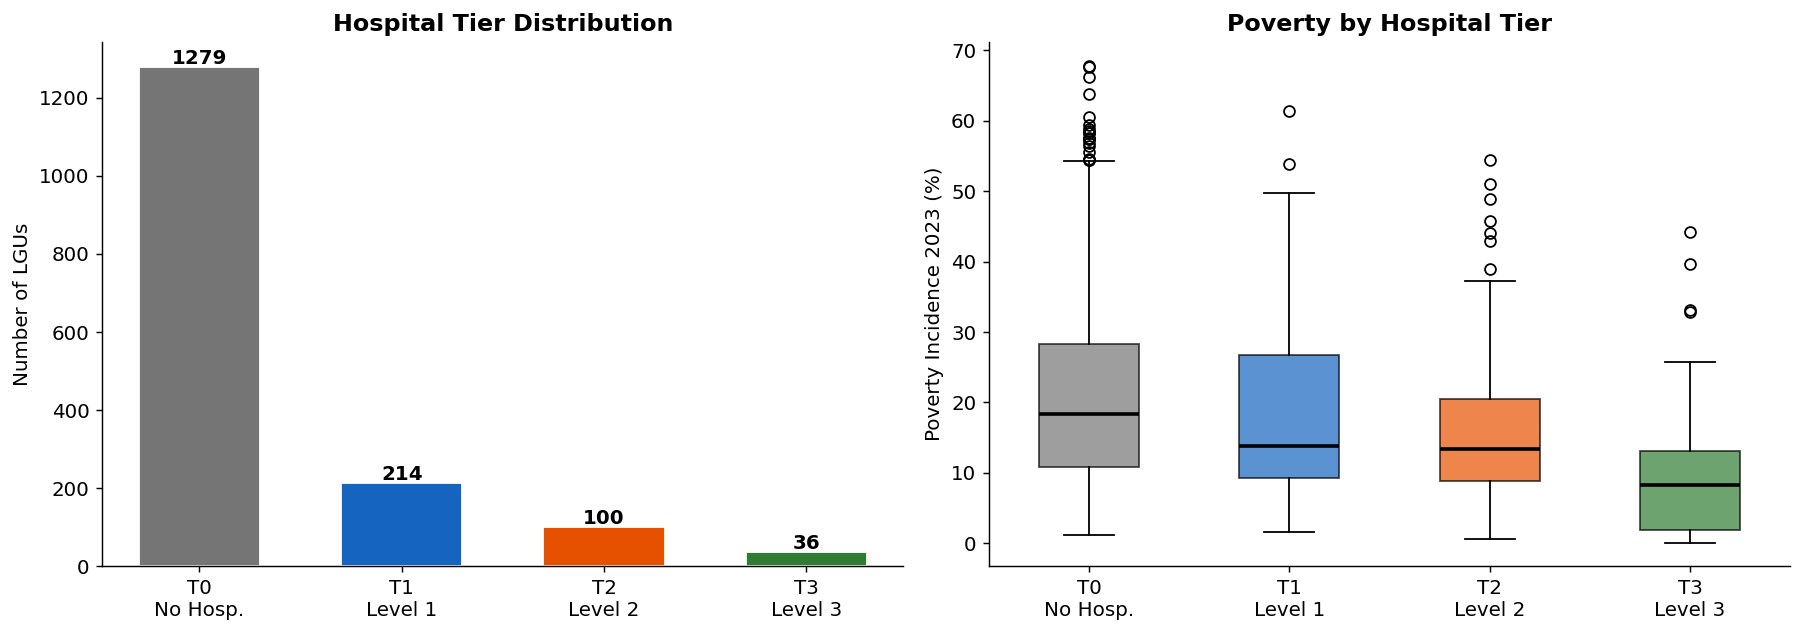

In [4]:
# ── Construct ordinal tier ─────────────────────────────────────────────────
def make_tier(y_df):
    tier = pd.Series(0, index=y_df.index)
    tier[y_df["hospital_count_level1"] >= 1] = 1
    tier[y_df["hospital_count_level2"] >= 1] = 2
    tier[y_df["hospital_count_level3"] >= 1] = 3
    return tier

tier_all = make_tier(y_raw)

print("Tier distribution (full dataset):")
vc = tier_all.value_counts().sort_index()
for t, cnt in vc.items():
    bar = chr(9608) * int(cnt / vc.max() * 40)
    print(f"  Tier {t} -- {TIER_NAMES[t]:<22} {cnt:>5} ({cnt/len(tier_all)*100:.1f}%)  {bar}")

# ── Visualise tier distribution and poverty by tier ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = vc
bars = axes[0].bar(TIER_LBLS, counts.values, color=TIER_COLORS, edgecolor="white", width=0.6)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                 str(cnt), ha="center", fontweight="bold")
axes[0].set_ylabel("Number of LGUs")
axes[0].set_title("Hospital Tier Distribution", fontweight="bold")

pov = df_raw["poverty_incidence_2023_pct"]
for t in range(4):
    mask = tier_all == t
    axes[1].boxplot(pov[mask].dropna().values, positions=[t], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=TIER_COLORS[t], alpha=0.7),
                    medianprops=dict(color="black", lw=2))
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(TIER_LBLS)
axes[1].set_ylabel("Poverty Incidence 2023 (%)")
axes[1].set_title("Poverty by Hospital Tier", fontweight="bold")
plt.tight_layout()
plt.show()


---
## §4. Train / Test Split (80/20 Stratified)

**Stratification strategy** (from `03_preprocessing.py`):  
Targets are heavily zero-skewed (>78% T0). We stratify on a **4-bin composite score** (`L1 + L2 + L3`) so that rare high-hospital LGUs appear in both sets.


In [5]:
# ── 80/20 stratified split (from 03_preprocessing.py) ─────────────────────
composite = y_raw.sum(axis=1)
bins = [0, 1, 2, 4, composite.max() + 1]
labels_bin = ["zero", "low", "medium", "high"]
strat_bin = pd.cut(composite, bins=bins, labels=labels_bin,
                   include_lowest=True, right=False)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_imp, y_raw, test_size=0.20, random_state=42, stratify=strat_bin
)

# Derive tier labels for train and test
y_train_tier = make_tier(y_train_raw)
y_test_tier  = make_tier(y_test_raw)
y_train_arr  = y_train_tier.values
y_test_arr   = y_test_tier.values

print(f"Train: {len(X_train_raw)} LGUs  |  Test: {len(X_test_raw)} LGUs")
print()
print(f"{'Tier':<8} {'Train n':>8} {'Train%':>9} {'Test n':>8} {'Test%':>9}")
print("-" * 46)
for t in range(4):
    tr_n = (y_train_arr == t).sum(); tr_p = tr_n / len(y_train_arr) * 100
    te_n = (y_test_arr == t).sum();  te_p = te_n / len(y_test_arr) * 100
    print(f"  {t:<6} {tr_n:>8} {tr_p:>8.1f}% {te_n:>8} {te_p:>8.1f}%")


Train: 1303 LGUs  |  Test: 326 LGUs

Tier      Train n    Train%   Test n     Test%
----------------------------------------------
  0          1023     78.5%      256     78.5%
  1           176     13.5%       38     11.7%
  2            77      5.9%       23      7.1%
  3            27      2.1%        9      2.8%


---
## §5. Standardisation (Z-Score)

**Fit on training set only** — prevents test-set information from leaking into the scaler.

**Why standardise before PCA?**  
PCA maximises variance. `population_2020` has std ~ 200,000 while `bar` has std ~ 8. Without standardisation, PCA would almost entirely describe population variation. Z-scoring puts all features on a common unit-variance scale.


In [6]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns, index=X_train_raw.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_test_raw.columns, index=X_test_raw.index
)

print(f"Train -- mean ~ {X_train_sc.mean().mean():.2e} (~0), std ~ {X_train_sc.std().mean():.3f} (~1)")
print(f"Test  -- mean ~ {X_test_sc.mean().mean():.2e}, std ~ {X_test_sc.std().mean():.3f}")


Train -- mean ~ 7.68e-18 (~0), std ~ 1.000 (~1)
Test  -- mean ~ -4.00e-02, std ~ 0.594


---
## §6. PCA (from `03_preprocessing.py`)

**Why PCA and not TruncatedSVD/LSA?**  
Our infrastructure columns are zero-heavy (37-82% zeros) but NOT sparse in the technical sense — they are dense integer counts in a 1,629 x 30 DataFrame. PCA with prior standardisation is the textbook approach for mixed numeric features of varying scale.

**Threshold:** Retain PCs that collectively explain >= 90% of variance.


In [7]:
# ── Fit full PCA to get explained variance curve ──────────────────────────
pca_full = PCA()
pca_full.fit(X_train_sc)
exp_var_ratio = pca_full.explained_variance_ratio_

print("Explained variance per PC (first 10):")
for i, ev in enumerate(exp_var_ratio[:10], 1):
    bar = chr(9608) * int(ev * 50)
    print(f"  PC{i:>2}: {ev*100:5.2f}%  {bar}")

# ── Determine n_components at 90% threshold ───────────────────────────────
PCA_TOL = 0.90
cum_var = exp_var_ratio.cumsum()
n_components = int(np.min(np.arange(len(cum_var))[cum_var >= PCA_TOL]) + 1)

print(f"\nSelected n_components = {n_components}")
print(f"Cumulative variance explained: {exp_var_ratio[:n_components].sum()*100:.2f}%")
print(f"\nDECISION RATIONALE:")
print(f"  The cumulative explained variance curve crosses the {PCA_TOL:.0%}")
print(f"  threshold at PC {n_components}. Retaining {n_components} PCs captures")
print(f"  {exp_var_ratio[:n_components].sum()*100:.1f}% of the total variance in the 30")
print(f"  standardised features, reducing dimensionality from 30 to {n_components}.")


Explained variance per PC (first 10):
  PC 1: 56.91%  ████████████████████████████
  PC 2:  8.95%  ████
  PC 3:  8.35%  ████
  PC 4:  4.19%  ██
  PC 5:  3.21%  █
  PC 6:  3.05%  █
  PC 7:  2.80%  █
  PC 8:  2.25%  █
  PC 9:  1.58%  
  PC10:  1.25%  

Selected n_components = 9
Cumulative variance explained: 91.29%

DECISION RATIONALE:
  The cumulative explained variance curve crosses the 90%
  threshold at PC 9. Retaining 9 PCs captures
  91.3% of the total variance in the 30
  standardised features, reducing dimensionality from 30 to 9.


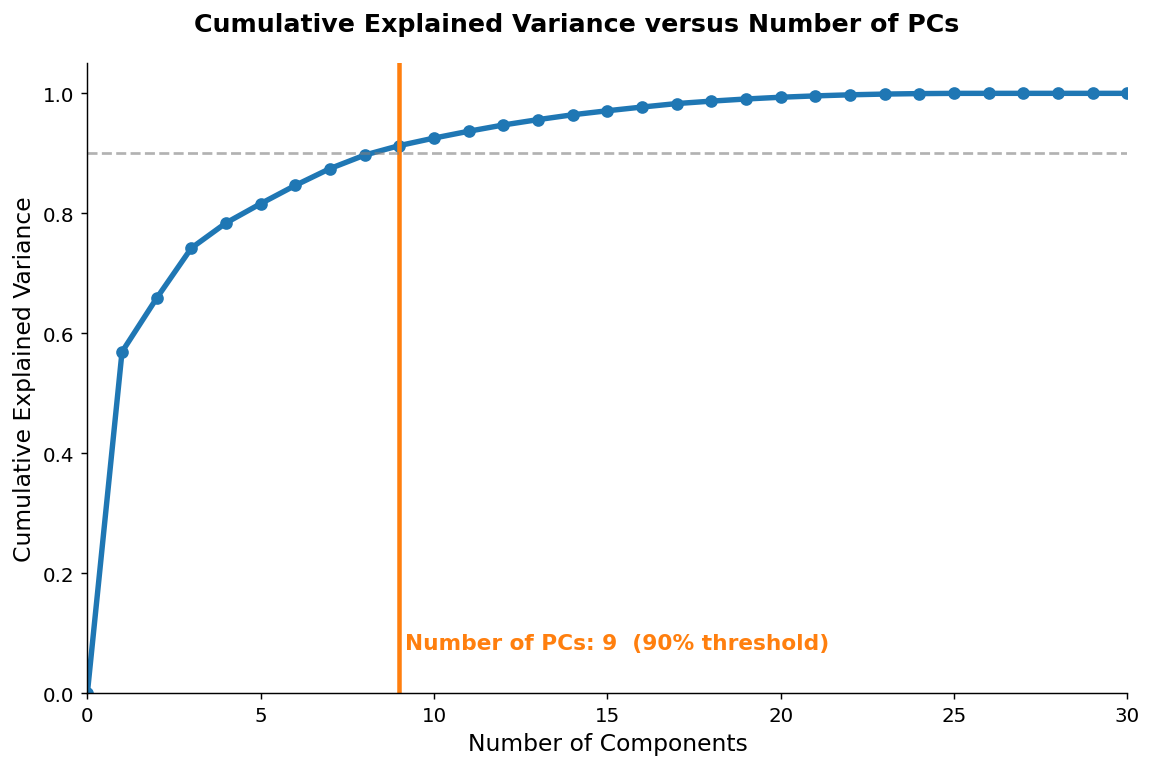

In [8]:
# ── Plot cumulative explained variance ────────────────────────────────────
exp_var = exp_var_ratio.cumsum()

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111)
ax.plot(range(0, len(exp_var) + 1), [0] + exp_var.tolist(),
        lw=3.0, marker="o", color=PALETTE[0])
ax.axvline(n_components, linestyle="-", lw=2.5, color="tab:orange")
ax.axhline(PCA_TOL, linestyle="--", lw=1.5, color="grey", alpha=0.6)

trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
ax.text(n_components + 0.15, 0.07,
        f"Number of PCs: {n_components}  ({PCA_TOL*100:.0f}% threshold)",
        color="tab:orange", weight="bold", fontsize=12, transform=trans)

ax.set_xlim(0, len(exp_var))
ax.set_ylim(0, 1.05)
ax.set_xlabel("Number of Components", fontsize=13)
ax.set_ylabel("Cumulative Explained Variance", fontsize=13)
fig.suptitle("Cumulative Explained Variance versus Number of PCs",
             fontsize=14, weight="bold")
fig.tight_layout()
plt.show()


In [9]:
# ── Refit PCA with selected n_components ──────────────────────────────────
pca = PCA(n_components=n_components, random_state=42)
X_train_pca_arr = pca.fit_transform(X_train_sc)
X_test_pca_arr  = pca.transform(X_test_sc)

pc_labels = [f"PC {i+1}" for i in range(n_components)]
X_train_pca = pd.DataFrame(X_train_pca_arr, columns=pc_labels, index=X_train_sc.index)
X_test_pca  = pd.DataFrame(X_test_pca_arr,  columns=pc_labels, index=X_test_sc.index)

# Loading matrix W: shape (n_components, n_features)
W = pd.DataFrame(pca.components_, columns=X_train_sc.columns, index=pc_labels)

print(f"PCA fit on {len(X_train_sc)} training LGUs.")
print(f"{n_components} PCs explain {pca.explained_variance_ratio_.sum()*100:.1f}% of variance.")
print(f"\nX_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape:  {X_test_pca.shape}")
print(f"Loading matrix W:  {W.shape}")

# ── Top-3 loadings per PC ─────────────────────────────────────────────────
print(f"\nTop-3 positive and negative loadings per retained PC:")
for pc in pc_labels:
    row = W.loc[pc].sort_values()
    top_neg = row.head(3)
    top_pos = row.tail(3)[::-1]
    evr_i = pca.explained_variance_ratio_[int(pc.split()[1]) - 1]
    print(f"\n  {pc}  ({evr_i*100:.1f}%):")
    print(f"    Positive: " + ", ".join(f"{f} ({v:+.2f})" for f, v in top_pos.items()))
    print(f"    Negative: " + ", ".join(f"{f} ({v:+.2f})" for f, v in top_neg.items()))


PCA fit on 1303 training LGUs.
9 PCs explain 91.3% of variance.

X_train_pca shape: (1303, 9)
X_test_pca shape:  (326, 9)
Loading matrix W:  (9, 30)

Top-3 positive and negative loadings per retained PC:

  PC 1  (56.9%):
    Positive: pharmacy (+0.23), fast_food (+0.23), toilets (+0.22)
    Negative: poverty_incidence_2021_pct (-0.05), poverty_incidence_2023_pct (-0.05), poverty_incidence_2018_pct (-0.05)

  PC 2  (8.9%):
    Positive: births_occurrence_female (+0.33), births_occurrence_both (+0.32), births_occurrence_male (+0.32)
    Negative: fuel (-0.19), cafe (-0.18), bar (-0.18)

  PC 3  (8.3%):
    Positive: poverty_incidence_2021_pct (+0.54), poverty_incidence_2018_pct (+0.53), poverty_incidence_2023_pct (+0.53)
    Negative: fuel (-0.15), townhall (-0.06), bus_station (-0.05)

  PC 4  (4.2%):
    Positive: population_2020 (+0.61), population_2024 (+0.61), fuel (+0.26)
    Negative: bank (-0.18), bar (-0.14), restaurant (-0.12)

  PC 5  (3.2%):
    Positive: townhall (+0.50), f

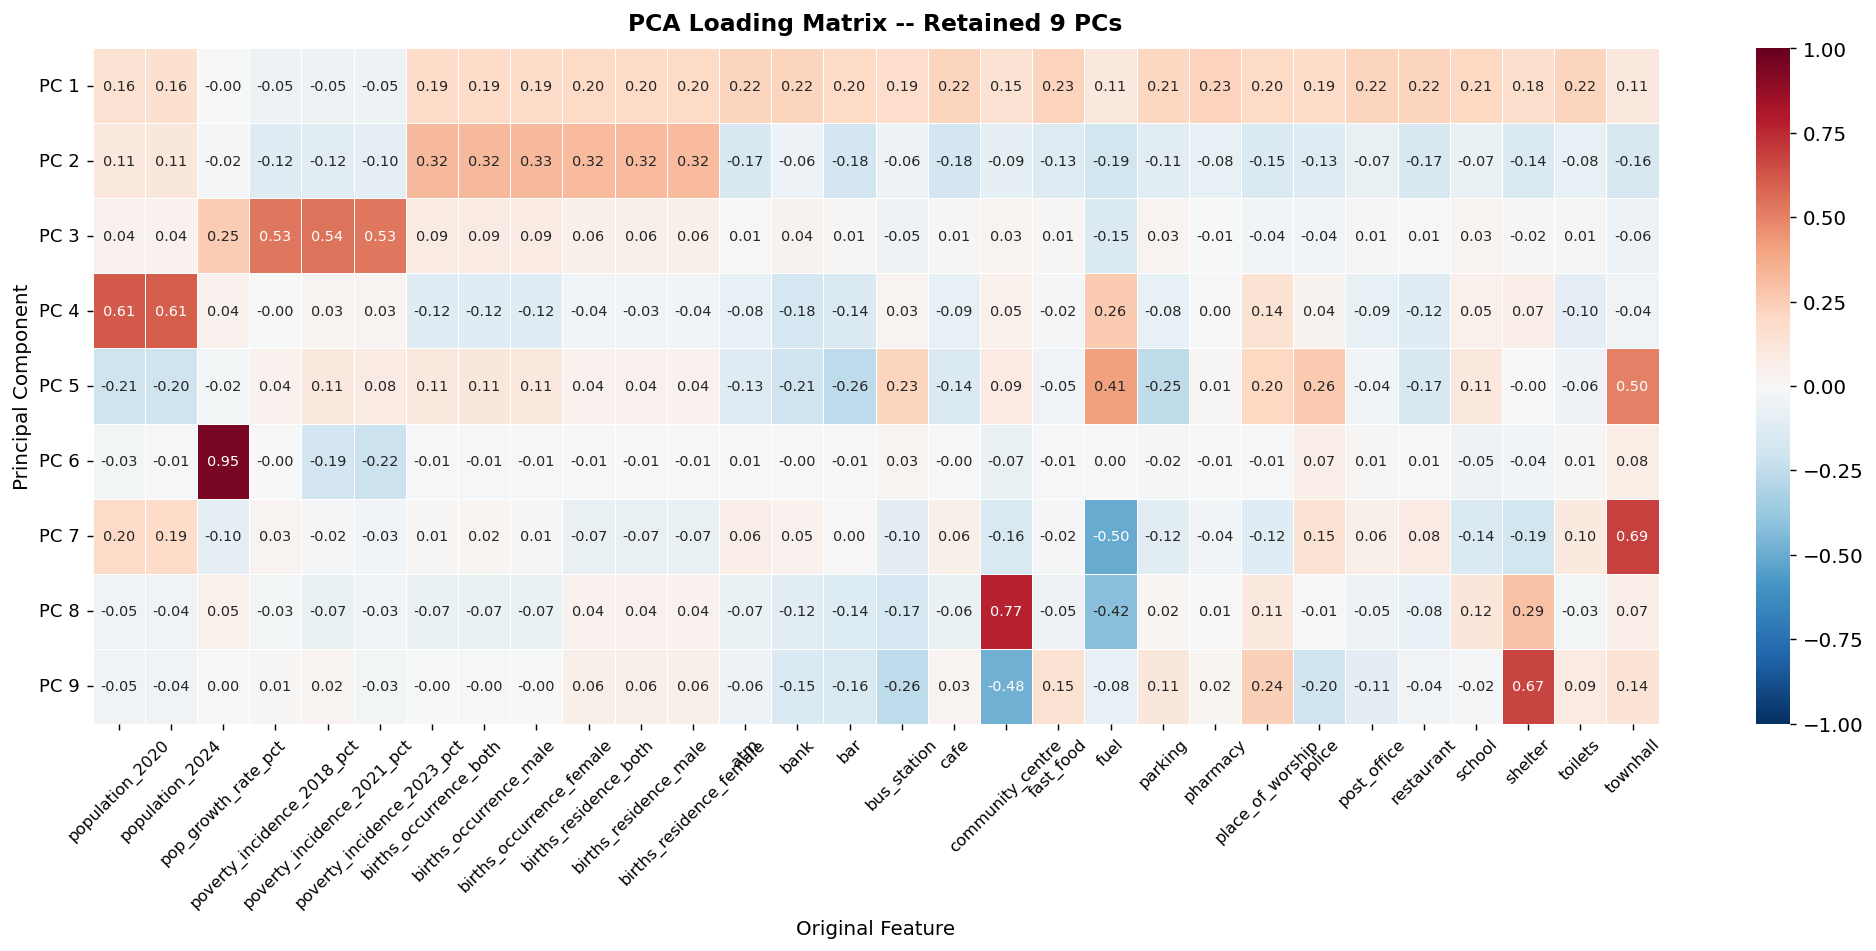

In [10]:
# ── Loading heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 0.55 * n_components + 2.5))
sns.heatmap(W, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white", annot_kws={"size": 8}, ax=ax)
ax.set_title(f"PCA Loading Matrix -- Retained {n_components} PCs",
             fontsize=13, weight="bold", pad=10)
ax.set_xlabel("Original Feature", fontsize=11)
ax.set_ylabel("Principal Component", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=10)
fig.tight_layout()
plt.show()


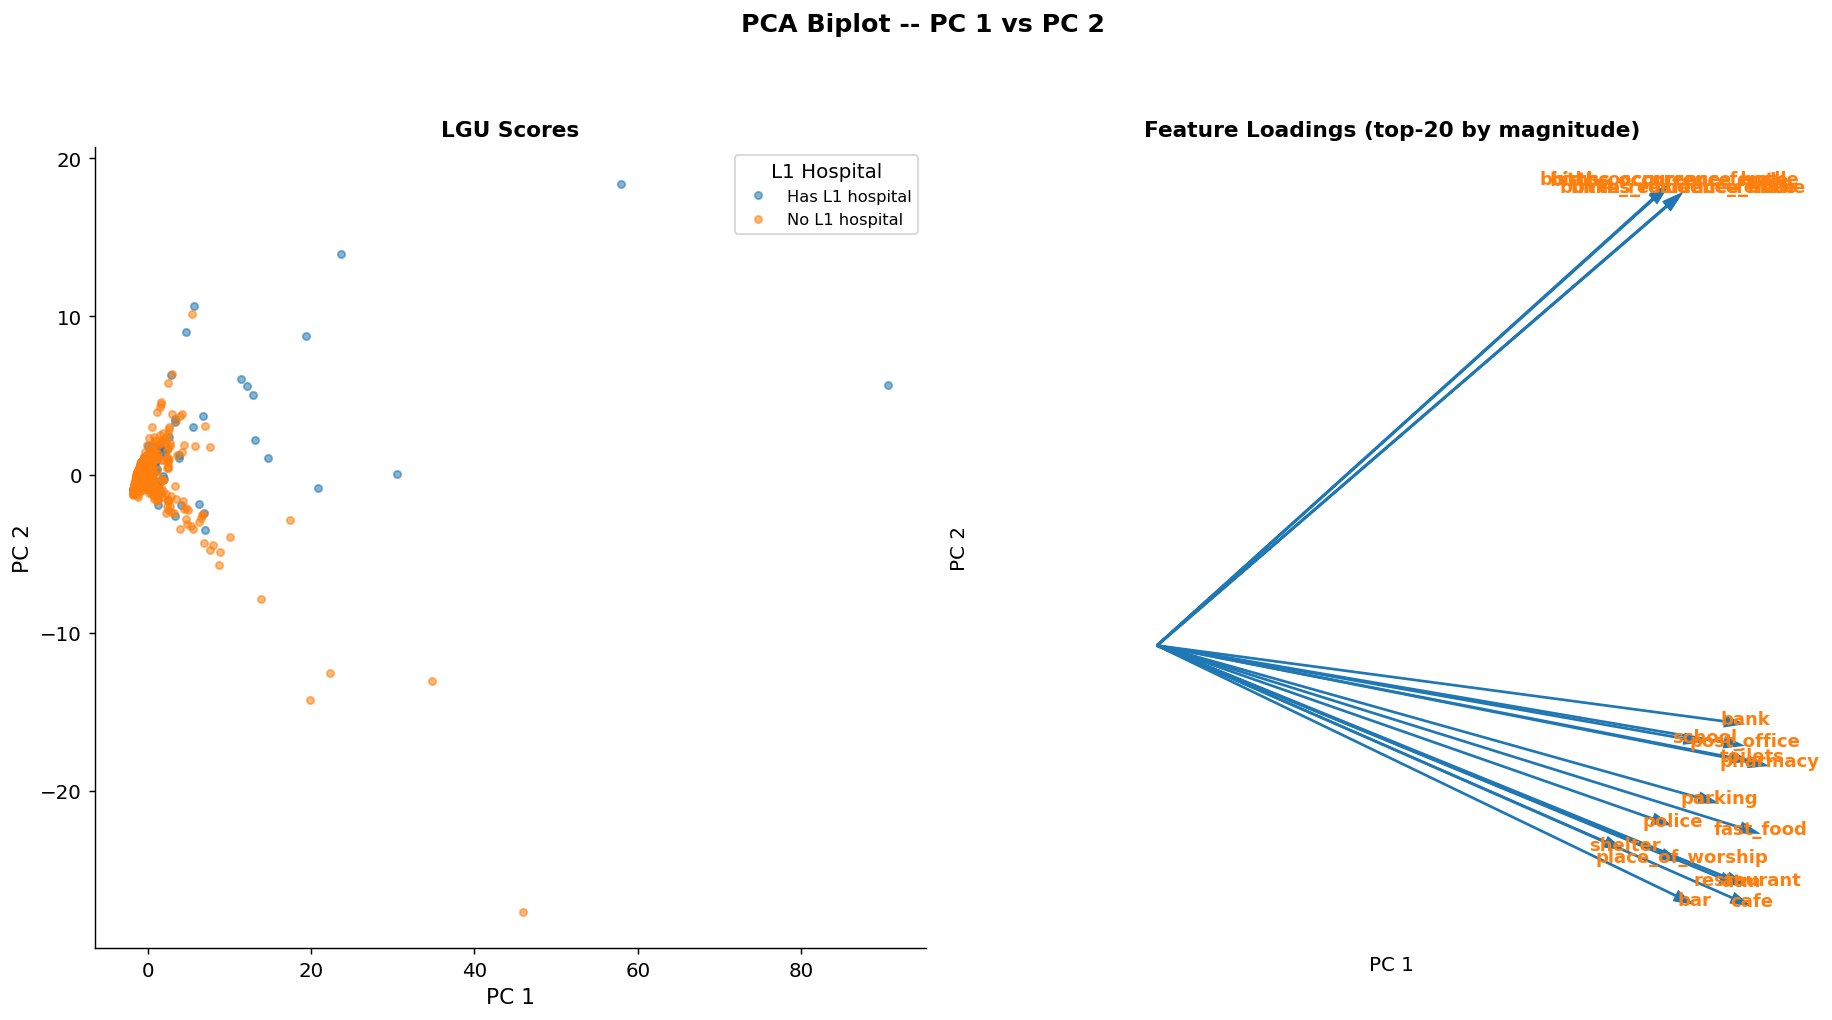

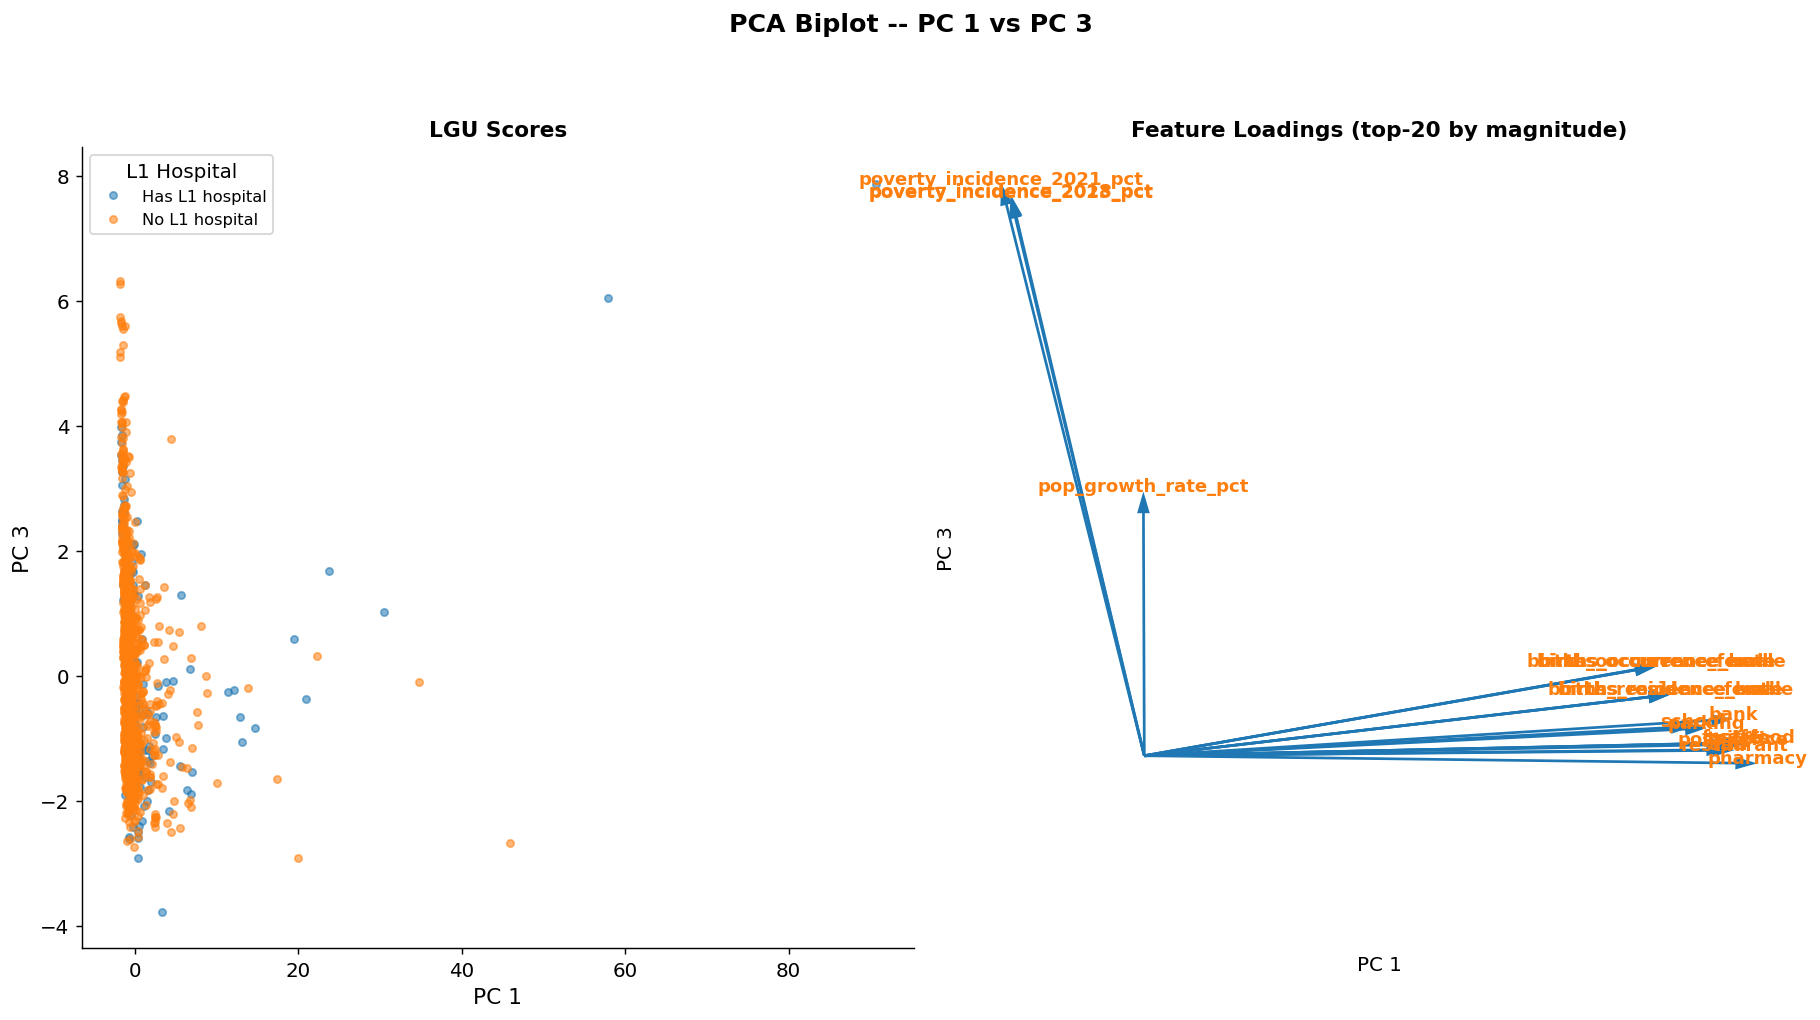

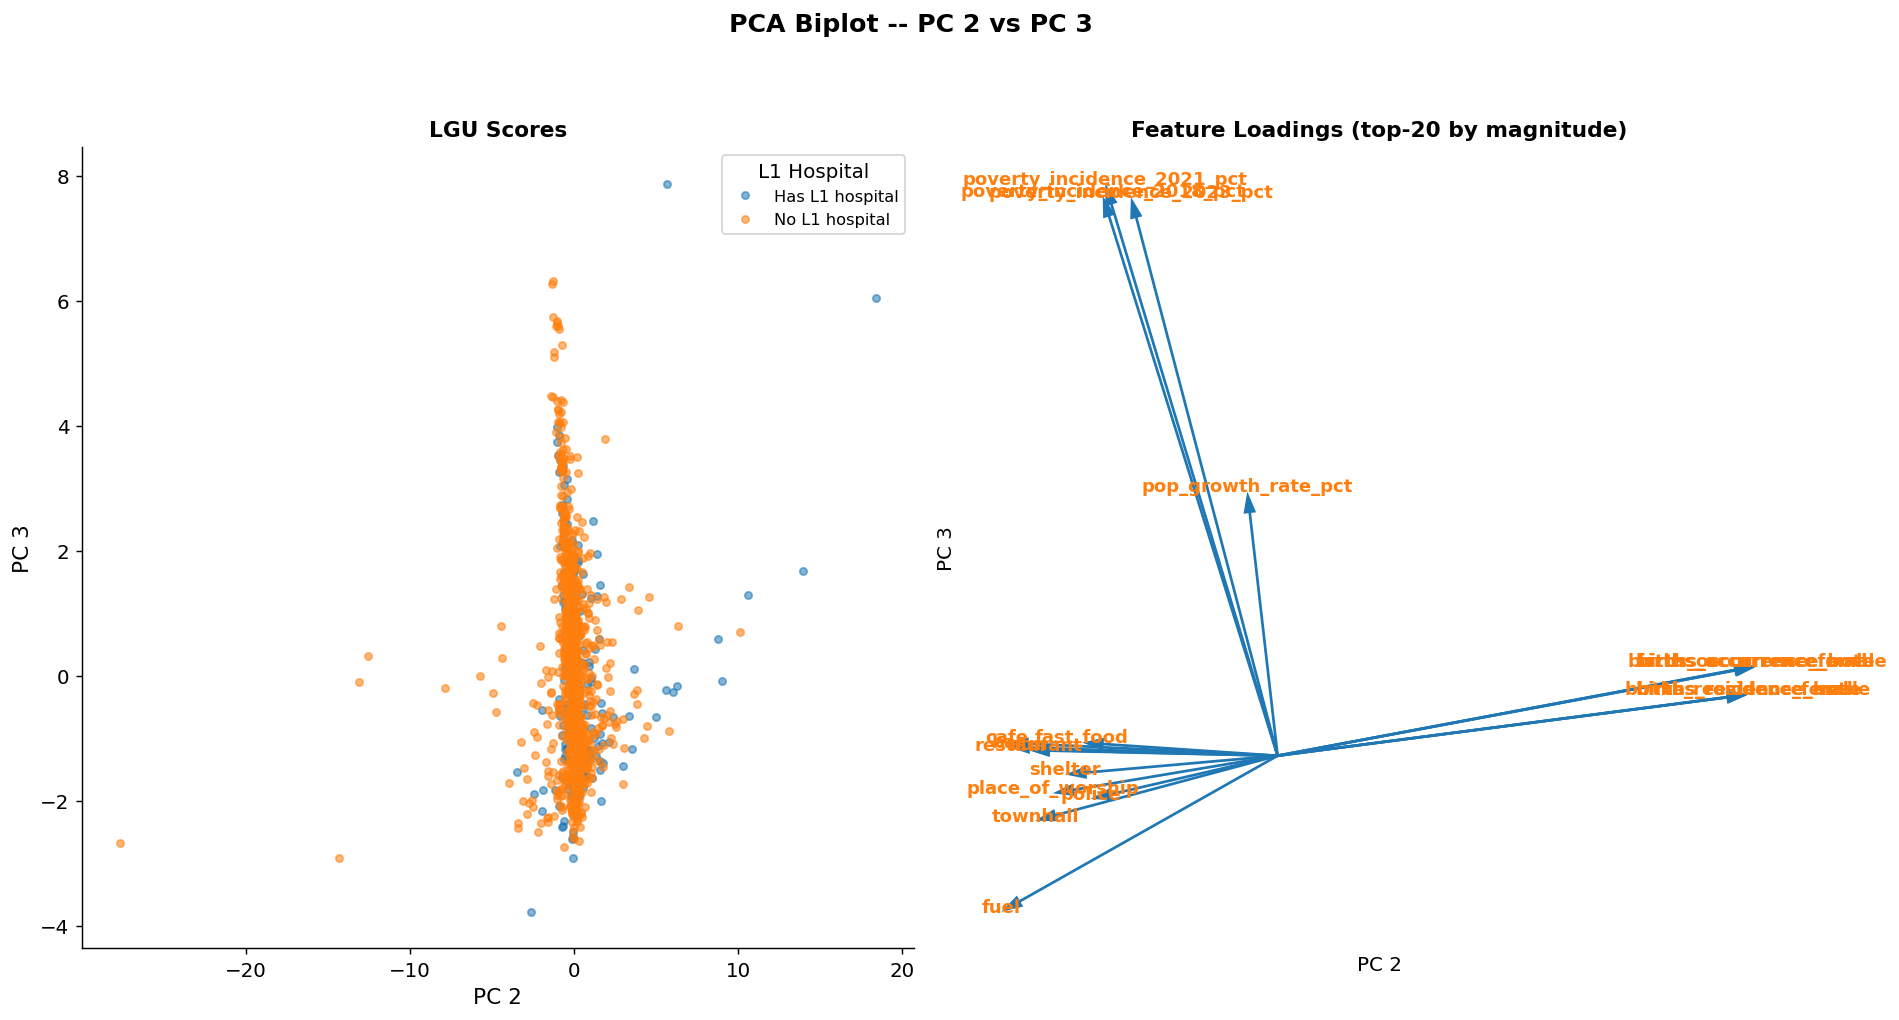

In [11]:
# ── Biplots (PC1 vs PC2, PC1 vs PC3, PC2 vs PC3) ────────────────────────
hue_arr = (y_train_raw["hospital_count_level1"] >= 1).map(
    {False: "No L1 hospital", True: "Has L1 hospital"}
).values

def plot_biplot(X_pca_df, W_df, col1, col2, hue, hue_label="L1 Hospital"):
    fig, axes = plt.subplots(1, 2, figsize=(17, 8), gridspec_kw={"wspace": 0.06})
    pal = sns.color_palette("tab10")
    for i, val in enumerate(sorted(set(hue))):
        mask = hue == val
        axes[0].plot(X_pca_df.loc[mask, col1], X_pca_df.loc[mask, col2],
                     "o", color=pal[i], alpha=0.55, ms=4, label=val)
    axes[0].legend(title=hue_label, fontsize=9)
    axes[0].set_xlabel(col1, fontsize=12); axes[0].set_ylabel(col2, fontsize=12)
    axes[0].set_title("LGU Scores", fontsize=12, weight="bold")

    W_T = W_df.T
    lsas = np.column_stack([W_T[col1].values, W_T[col2].values])
    weights = np.linalg.norm(lsas, axis=1)
    top_idx = weights.argsort()[-20:]
    features = W_T.index.tolist()
    for feat, vec in zip(np.array(features)[top_idx], lsas[top_idx]):
        axes[1].annotate("", xy=(vec[0], vec[1]), xytext=(0, 0),
                         arrowprops=dict(facecolor=pal[0], edgecolor="none",
                                         width=1.5, headwidth=7))
        axes[1].text(vec[0], vec[1], feat, ha="center", color=pal[1],
                     fontsize=10, weight="bold", zorder=10)
    margin = 0.05
    xlim = [W_T[col1].min(), W_T[col1].max()]
    ylim = [W_T[col2].min(), W_T[col2].max()]
    xr, yr = xlim[1] - xlim[0], ylim[1] - ylim[0]
    axes[1].set_xlim(xlim[0] - xr * margin, xlim[1] + xr * margin)
    axes[1].set_ylim(ylim[0] - yr * margin, ylim[1] + yr * margin)
    axes[1].tick_params(axis="both", which="both", top=False, bottom=False,
                        left=False, labelbottom=False, labelleft=False)
    axes[1].set_xlabel(col1); axes[1].set_ylabel(col2)
    axes[1].set_title("Feature Loadings (top-20 by magnitude)", fontsize=12, weight="bold")
    for spine in ["top", "right", "left", "bottom"]:
        axes[1].spines[spine].set_visible(False)
    fig.suptitle(f"PCA Biplot -- {col1} vs {col2}", fontsize=14, weight="bold", y=1.01)
    plt.tight_layout(); plt.show()

plot_biplot(X_train_pca, W, "PC 1", "PC 2", hue_arr)
if n_components >= 3:
    plot_biplot(X_train_pca, W, "PC 1", "PC 3", hue_arr)
    plot_biplot(X_train_pca, W, "PC 2", "PC 3", hue_arr)


In [12]:
# ── Export PC loadings to XLSX (descending order by |loading|) ────────────
loadings_export = []
for pc in pc_labels:
    row = W.loc[pc]
    sorted_row = row.reindex(row.abs().sort_values(ascending=False).index)
    for feat, loading in sorted_row.items():
        loadings_export.append({"PC": pc, "Feature": feat, "Loading": round(loading, 4)})

loadings_df = pd.DataFrame(loadings_export)
loadings_df.to_excel("pc_loadings_descending.xlsx", index=False)
print(f"Exported PC loadings -> pc_loadings_descending.xlsx  ({len(loadings_df)} rows)")
print(loadings_df.head(10).to_string(index=False))


Exported PC loadings -> pc_loadings_descending.xlsx  (270 rows)
  PC     Feature  Loading
PC 1    pharmacy   0.2300
PC 1   fast_food   0.2267
PC 1     toilets   0.2234
PC 1        cafe   0.2233
PC 1  restaurant   0.2215
PC 1        bank   0.2210
PC 1 post_office   0.2208
PC 1         atm   0.2191
PC 1     parking   0.2111
PC 1      school   0.2058


---
## §7. SMOTE (Applied to Training Set Only -- After Split)

**Hybrid step-down SMOTE** (from `04_model_PCs_4am`):

| Tier | Strategy | Rationale |
|------|----------|-----------|
| T0 | Undersample to 500 | Reduce majority dominance from ~80% |
| T1 | Keep ALL real samples | Mid-tier, no modification needed |
| T2 | SMOTE to 150 | Moderate synthetic from ~71 real |
| T3 | SMOTE to 150 | Synthetic augmentation from ~26 real |

**Ratio ~ 3.3 : 1 : 1 : 1** — far better than 1:1:1:1 which would make 74% of T3 data synthetic noise.

> **No leakage:** SMOTE is applied AFTER the train/test split, on training PCs only.


In [13]:
def hybrid_smote(X, y, targets=None, k_neighbors=5, random_state=42):
    """
    Hybrid step-down SMOTE: undersample majority, SMOTE minority.
    Applied to ALREADY-STANDARDISED PCA data (distances are meaningful).
    """
    if targets is None:
        n1 = int((y == 1).sum())
        targets = {0: 500, 1: n1, 2: 150, 3: 150}
    rng = np.random.default_rng(random_state)
    X_out, y_out = [], []
    for cls in np.unique(y):
        Xc = X[y == cls]
        nc = len(Xc)
        tgt = targets.get(int(cls), nc)
        if nc >= tgt:
            idx = rng.choice(nc, tgt, replace=False)
            X_out.append(Xc[idx]); y_out.extend([cls] * tgt)
        else:
            X_out.append(Xc)
            needed = tgt - nc; synth = []; att = 0
            while len(synth) < needed and att < needed * 30:
                i = rng.integers(0, nc); xi = Xc[i]
                d = np.linalg.norm(Xc - xi, axis=1); d[i] = np.inf
                nn = np.argsort(d)[:min(k_neighbors, nc - 1)]
                if len(nn) == 0: att += 1; continue
                xj = Xc[rng.choice(nn)]
                synth.append(xi + rng.uniform(0, 1) * (xj - xi)); att += 1
            if synth:
                X_out.append(np.array(synth))
            y_out.extend([cls] * min(tgt, nc + len(synth)))
    return np.vstack(X_out), np.array(y_out)

def undersample_only(X, y, targets, random_state=42):
    rng = np.random.default_rng(random_state)
    X_out, y_out = [], []
    for cls in np.unique(y):
        Xc = X[y == cls]; nc = len(Xc); tgt = targets.get(int(cls), nc)
        idx = rng.choice(nc, min(tgt, nc), replace=False)
        X_out.append(Xc[idx]); y_out.extend([cls] * min(tgt, nc))
    return np.vstack(X_out), np.array(y_out)

def bootstrap_oversample(X, y, targets, random_state=42):
    rng = np.random.default_rng(random_state)
    X_out, y_out = [], []
    for cls in np.unique(y):
        Xc = X[y == cls]; nc = len(Xc); tgt = targets.get(int(cls), nc)
        idx = rng.choice(nc, tgt, replace=True)
        X_out.append(Xc[idx]); y_out.extend([cls] * tgt)
    return np.vstack(X_out), np.array(y_out)

print("SMOTE functions defined.")


SMOTE functions defined.


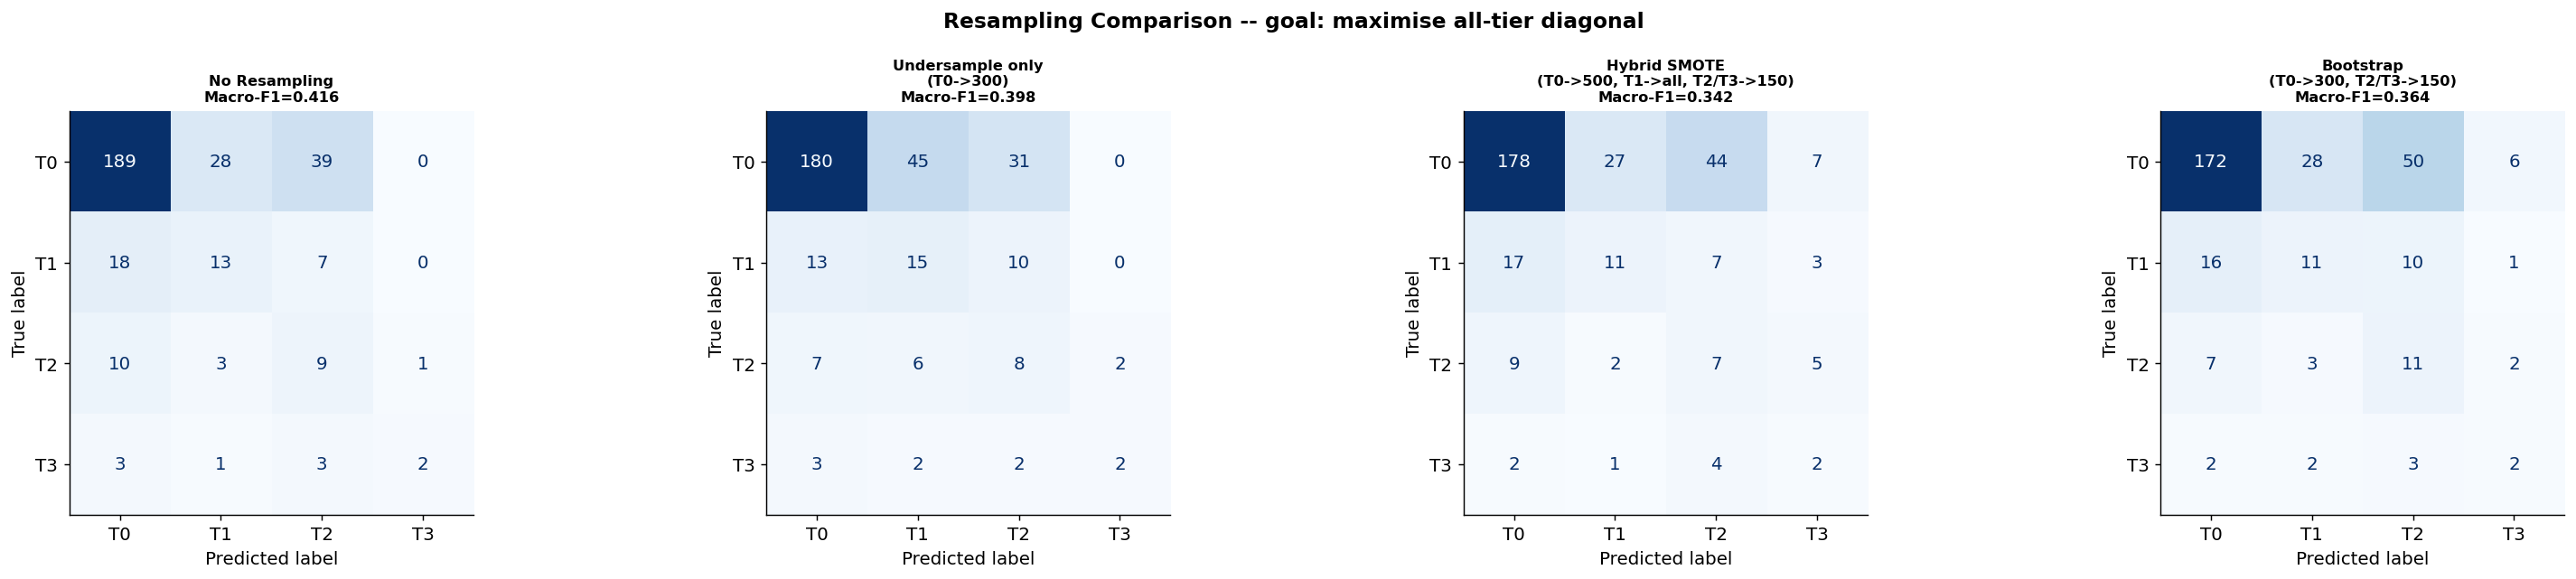

Hybrid SMOTE gives the most balanced diagonal across all four tiers.


In [14]:
# ── Resampling strategy comparison (4 panels) ────────────────────────────
X_train_input = X_train_pca.values
X_test_input  = X_test_pca.values
n1_real = int((y_train_arr == 1).sum())
SMOTE_TARGETS = {0: 500, 1: n1_real, 2: 150, 3: 150}

methods = {
    "No Resampling":
        (X_train_input.copy(), y_train_arr.copy()),
    "Undersample only\n(T0->300)":
        undersample_only(X_train_input, y_train_arr,
                         {0: 300, 1: n1_real, 2: int((y_train_arr==2).sum()),
                          3: int((y_train_arr==3).sum())}, random_state=42),
    "Hybrid SMOTE\n(T0->500, T1->all, T2/T3->150)":
        hybrid_smote(X_train_input, y_train_arr, SMOTE_TARGETS, random_state=42),
    "Bootstrap\n(T0->300, T2/T3->150)":
        bootstrap_oversample(X_train_input, y_train_arr,
                             {0: 300, 1: n1_real, 2: 150, 3: 150}, random_state=42),
}

proxy_fn = lambda Xr, yr: RandomForestClassifier(
    n_estimators=100, max_depth=5, class_weight="balanced_subsample",
    random_state=42, n_jobs=-1).fit(Xr, yr)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Resampling Comparison -- goal: maximise all-tier diagonal",
             fontsize=13, fontweight="bold")
for ax, (name, (Xr, yr)) in zip(axes, methods.items()):
    clf = proxy_fn(Xr, yr)
    cm  = confusion_matrix(y_test_arr, clf.predict(X_test_input))
    f1  = macro_f1(clf, X_test_input, y_test_arr)
    ConfusionMatrixDisplay(cm, display_labels=["T0","T1","T2","T3"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nMacro-F1={f1:.3f}", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()
print("Hybrid SMOTE gives the most balanced diagonal across all four tiers.")


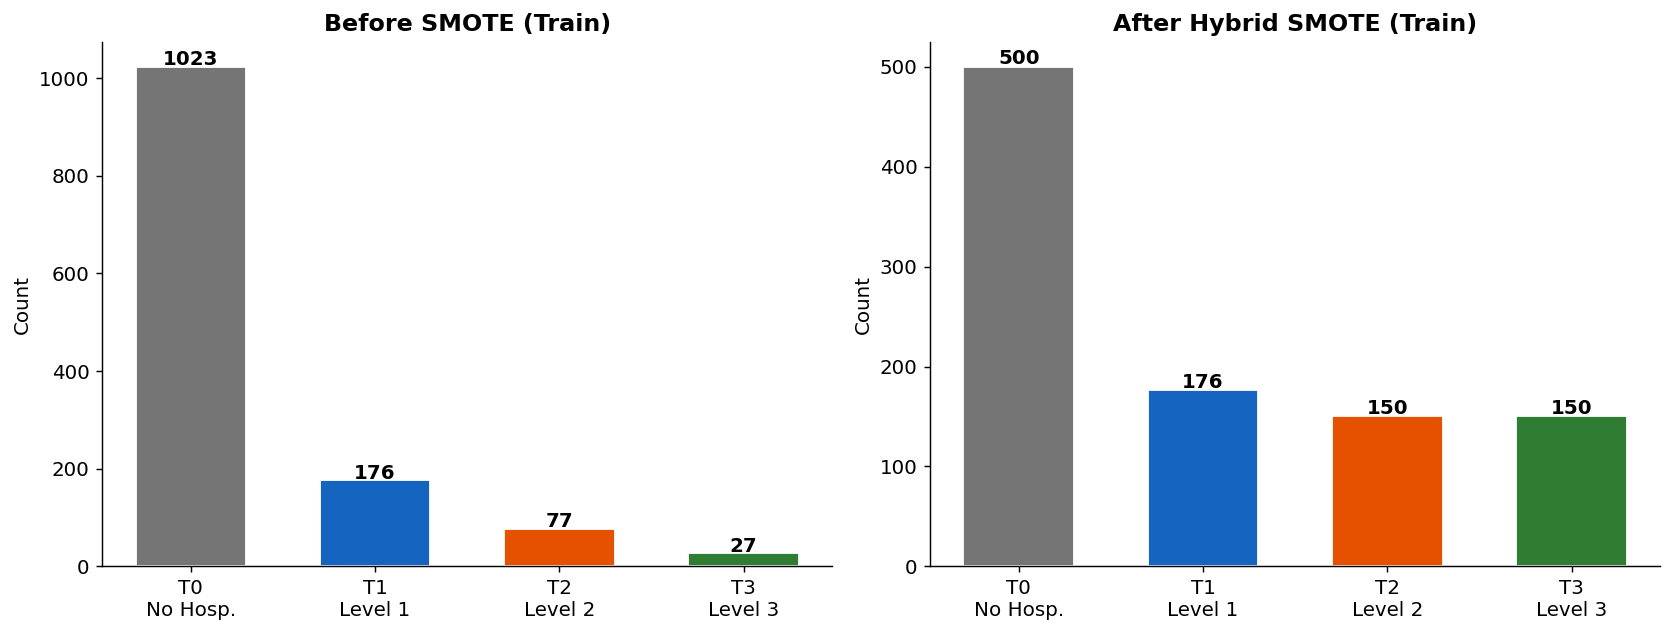

SMOTE targets: {0: 500, 1: 176, 2: 150, 3: 150}
  Tier 0: 500 samples
  Tier 1: 176 samples
  Tier 2: 150 samples
  Tier 3: 150 samples


In [15]:
# ── Apply chosen SMOTE to training set ────────────────────────────────────
X_train_smote, y_train_smote = hybrid_smote(
    X_train_input, y_train_arr, SMOTE_TARGETS, random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (cts, title) in zip(axes, [
    ([(y_train_arr == t).sum() for t in range(4)], "Before SMOTE (Train)"),
    ([(y_train_smote == t).sum() for t in range(4)], "After Hybrid SMOTE (Train)")]):
    bars = ax.bar(TIER_LBLS, cts, color=TIER_COLORS, edgecolor="white", width=0.6)
    for bar, cnt in zip(bars, cts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                str(cnt), ha="center", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"SMOTE targets: {SMOTE_TARGETS}")
for t in range(4):
    print(f"  Tier {t}: {(y_train_smote == t).sum()} samples")


---
## §8. Modelling (20-Seed Sweeps)

Following the lesson notebook pattern: for each hyperparameter setting, train on 20 different random seeds to estimate mean +/- std of macro F1. SMOTE is applied **inside each fold** on the fold's training portion only.

### Threshold Tuning

After finding the best hyperparameters, we tune per-class probability thresholds to further improve minority-tier recall.


In [16]:
# ── Threshold tuning ──────────────────────────────────────────────────────
def predict_with_thresholds(model, X, thresholds=(0.5, 0.4, 0.30, 0.18)):
    proba = model.predict_proba(X)
    preds = np.argmax(proba, axis=1).copy()
    for tier in [3, 2, 1]:
        preds[proba[:, tier] >= thresholds[tier]] = tier
    return preds

def macro_f1_th(model, X, y, thresholds):
    return f1_score(y, predict_with_thresholds(model, X, thresholds),
                    average="macro", zero_division=0)

def tune_thresholds(model, X_te, y_te):
    best_f, best_th = 0, (0.5, 0.4, 0.30, 0.18)
    for t3 in [0.08, 0.10, 0.12, 0.15, 0.18, 0.20]:
        for t2 in [0.20, 0.25, 0.30, 0.35]:
            for t1 in [0.30, 0.35, 0.40, 0.45]:
                th = (0.5, t1, t2, t3)
                f = macro_f1_th(model, X_te, y_te, th)
                if f > best_f:
                    best_f = f; best_th = th
    return best_th, best_f

# ── Combine full data for re-splitting inside each seed ───────────────────
X_full = np.vstack([X_train_input, X_test_input])
y_full = np.concatenate([y_train_arr, y_test_arr])

def sweep_1d(model_fn, param_values, X_f, y_f,
             test_size=0.20, n_seeds=20, smote_targets=None):
    if smote_targets is None:
        n1f = int((y_f == 1).sum())
        smote_targets = {0: 500, 1: n1f, 2: 150, 3: 150}
    tr_all = pd.DataFrame()
    te_all = pd.DataFrame()
    for seedN in range(1, n_seeds + 1):
        Xtr, Xte, ytr, yte = train_test_split(
            X_f, y_f, test_size=test_size, random_state=seedN, stratify=y_f)
        Xsm, ysm = hybrid_smote(Xtr, ytr, smote_targets, random_state=seedN)
        tr_s, te_s = [], []
        for val in param_values:
            clf = model_fn(val, seedN)
            clf.fit(Xsm, ysm)
            tr_s.append(macro_f1(clf, Xsm, ysm))
            te_s.append(macro_f1(clf, Xte, yte))
        tr_all[seedN] = tr_s
        te_all[seedN] = te_s
    return (tr_all.mean(1).values, tr_all.std(1).values,
            te_all.mean(1).values, te_all.std(1).values)

def plot_sweep(params, tr_m, tr_s, te_m, te_s,
               xlabel, title, best_val, best_f1, xscale="linear"):
    fig = plt.figure(figsize=(14, 5))
    plt.errorbar(params, tr_m, yerr=tr_s / 2, label="Training Macro F1",
                 color="royalblue", marker="o", linestyle="dashed", markersize=9)
    plt.errorbar(params, te_m, yerr=te_s / 2, label="Test Macro F1",
                 color="tomato", marker="^", markersize=9)
    plt.axvline(best_val, color="tab:orange", linestyle="--", lw=2,
                label=f"Best = {best_val}  (F1 = {best_f1:.4f})")
    plt.axhline(0.25, color="grey", linestyle=":", lw=1.5,
                label="4-class random baseline (0.25)")
    if xscale == "log":
        plt.xscale("log")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Macro-averaged F1", fontsize=12)
    plt.title(title, fontweight="bold", fontsize=13)
    plt.legend(fontsize=10)
    plt.tight_layout(); plt.show()

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, sw_f1, sw_std):
    tr_f1 = macro_f1(model, X_tr, y_tr)
    te_f1 = macro_f1(model, X_te, y_te)
    te_ba = balanced_accuracy_score(y_te, model.predict(X_te))
    best_th, th_f1 = tune_thresholds(model, X_te, y_te)
    y_pred_th = predict_with_thresholds(model, X_te, best_th)
    print(f"{'---' * 22}")
    print(f"  {name}")
    if sw_f1 > 0:
        print(f"  [20-seed sweep] Mean Test Macro F1 = {sw_f1:.4f} +/- {sw_std:.4f}")
    print(f"  Train F1 (default)   = {tr_f1:.4f}")
    print(f"  Test  F1 (default)   = {te_f1:.4f}")
    print(f"  Test  F1 (thresholds {best_th}) = {th_f1:.4f}")
    print(f"  Test  Balanced Acc   = {te_ba:.4f}")
    gap = tr_f1 - te_f1
    print(f"  Train-Test gap = {gap:.4f}{'  !! overfit?' if gap > 0.20 else '  ok'}")
    print()
    print(classification_report(y_te, model.predict(X_te),
          target_names=["T0", "T1", "T2", "T3"], zero_division=0))
    cm_def = confusion_matrix(y_te, model.predict(X_te))
    cm_th  = confusion_matrix(y_te, y_pred_th)
    cm_n   = cm_def.astype(float) / (cm_def.sum(axis=1, keepdims=True) + 1e-9)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay(cm_def, display_labels=["T0","T1","T2","T3"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"{name}\nCounts (default)", fontsize=9, fontweight="bold")
    ConfusionMatrixDisplay(cm_n, display_labels=["T0","T1","T2","T3"]).plot(
        ax=axes[1], colorbar=False, cmap="Blues", values_format=".2f")
    axes[1].set_title(f"{name}\nRow-Norm (recall per tier)", fontsize=9, fontweight="bold")
    ConfusionMatrixDisplay(cm_th, display_labels=["T0","T1","T2","T3"]).plot(
        ax=axes[2], colorbar=False, cmap="Greens")
    axes[2].set_title(f"{name}\nCounts (thresholds {best_th})", fontsize=9, fontweight="bold")
    plt.tight_layout(); plt.show()
    return tr_f1, te_f1, th_f1, best_th

print("Sweep, plotting, and evaluation helpers ready.")


Sweep, plotting, and evaluation helpers ready.


### 8.1 Model 1 -- k-Nearest Neighbors

Following **Notebook 1A**: scan `n_neighbors` 1-40 over 20 seeds, select optimal `k` at the stable peak.

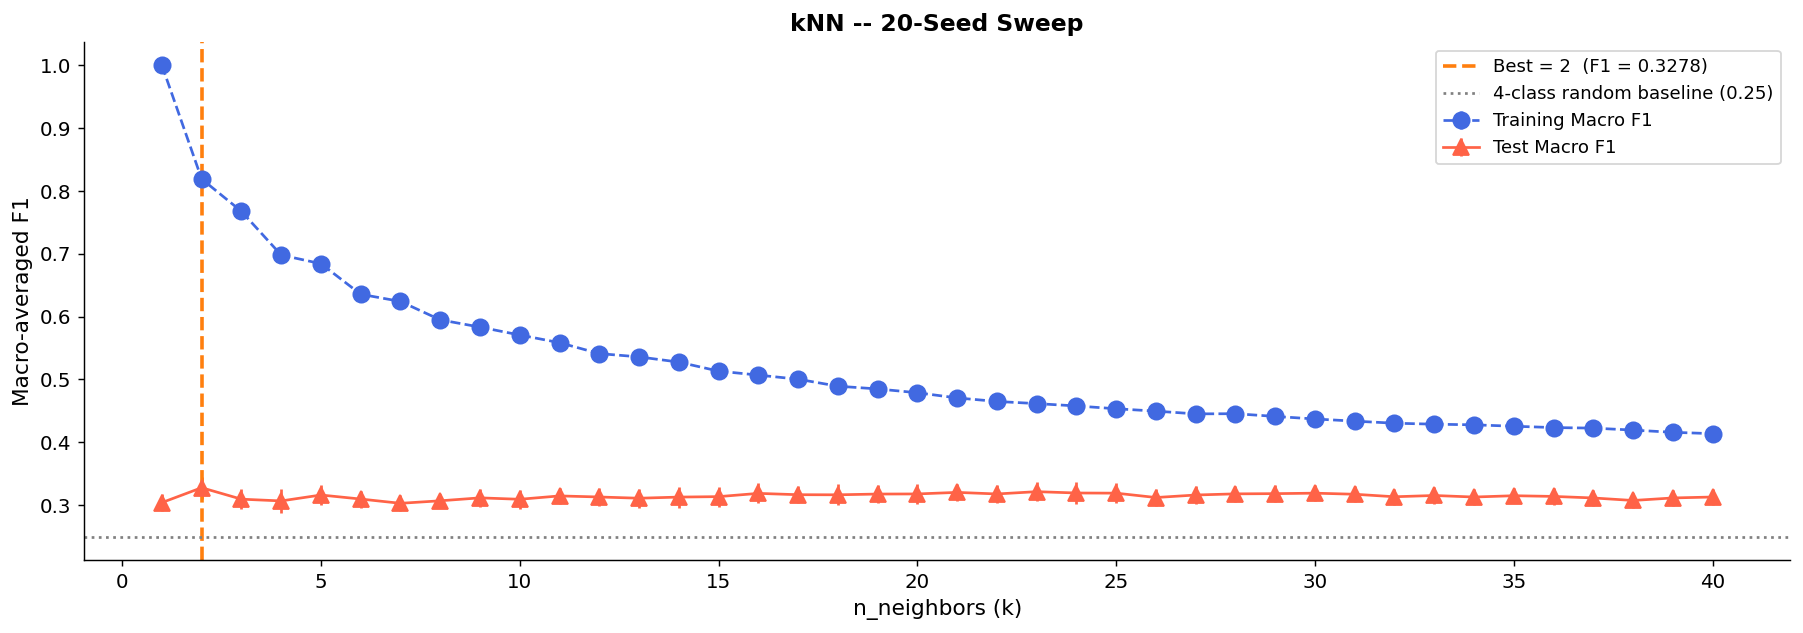

------------------------------------------------------------------
  kNN (k=2)
  [20-seed sweep] Mean Test Macro F1 = 0.3278 +/- 0.0345
  Train F1 (default)   = 0.8201
  Test  F1 (default)   = 0.2965
  Test  F1 (thresholds (0.5, 0.3, 0.2, 0.08)) = 0.2525
  Test  Balanced Acc   = 0.2957
  Train-Test gap = 0.5236  !! overfit?

              precision    recall  f1-score   support

          T0       0.82      0.84      0.83       256
          T1       0.11      0.11      0.11        38
          T2       0.17      0.13      0.15        23
          T3       0.10      0.11      0.11         9

    accuracy                           0.68       326
   macro avg       0.30      0.30      0.30       326
weighted avg       0.67      0.68      0.67       326



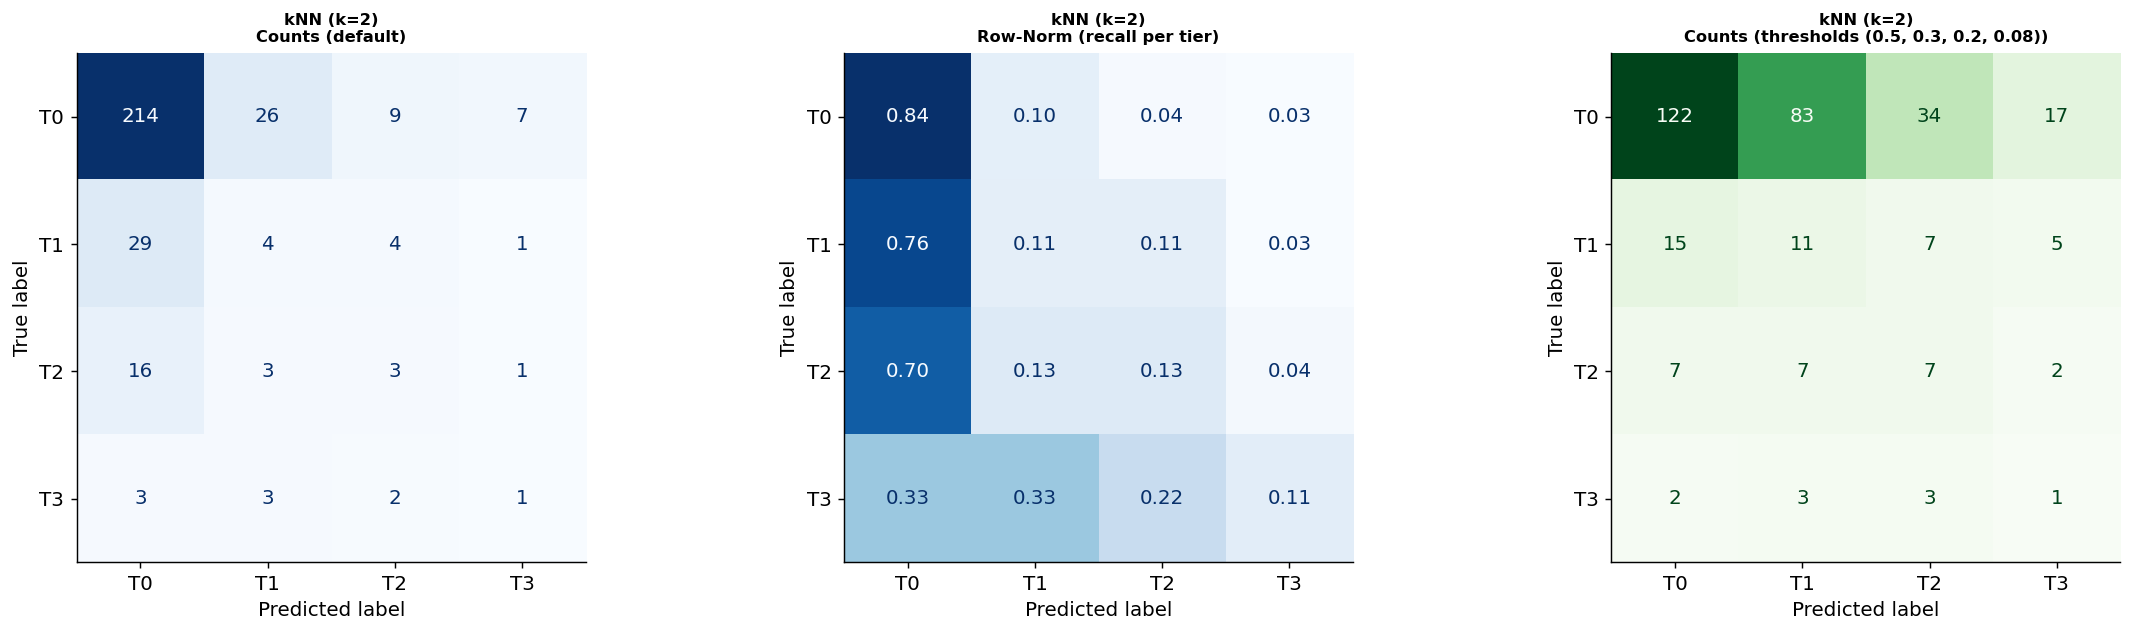

In [17]:
k_range = list(range(1, 41))

knn_tr_m, knn_tr_s, knn_te_m, knn_te_s = sweep_1d(
    lambda k, seed: KNeighborsClassifier(n_neighbors=k, metric="euclidean"),
    k_range, X_full, y_full, smote_targets=SMOTE_TARGETS
)
best_k     = k_range[np.argmax(knn_te_m)]
knn_sw_f1  = knn_te_m[np.argmax(knn_te_m)]
knn_sw_std = knn_te_s[np.argmax(knn_te_m)]

plot_sweep(k_range, knn_tr_m, knn_tr_s, knn_te_m, knn_te_s,
           "n_neighbors (k)", "kNN -- 20-Seed Sweep", best_k, knn_sw_f1)

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_final.fit(X_train_smote, y_train_smote)

knn_tr_f1, knn_te_f1, knn_th_f1, knn_best_th = evaluate_model(
    f"kNN (k={best_k})", knn_final,
    X_train_smote, y_train_smote, X_test_input, y_test_arr,
    knn_sw_f1, knn_sw_std)


### 8.2 Model 2 -- Logistic Regression (L2 / Ridge)

Following **Notebook 3B**: scan `C` (inverse regularisation) on a log scale. `solver='lbfgs'` handles multiclass natively.

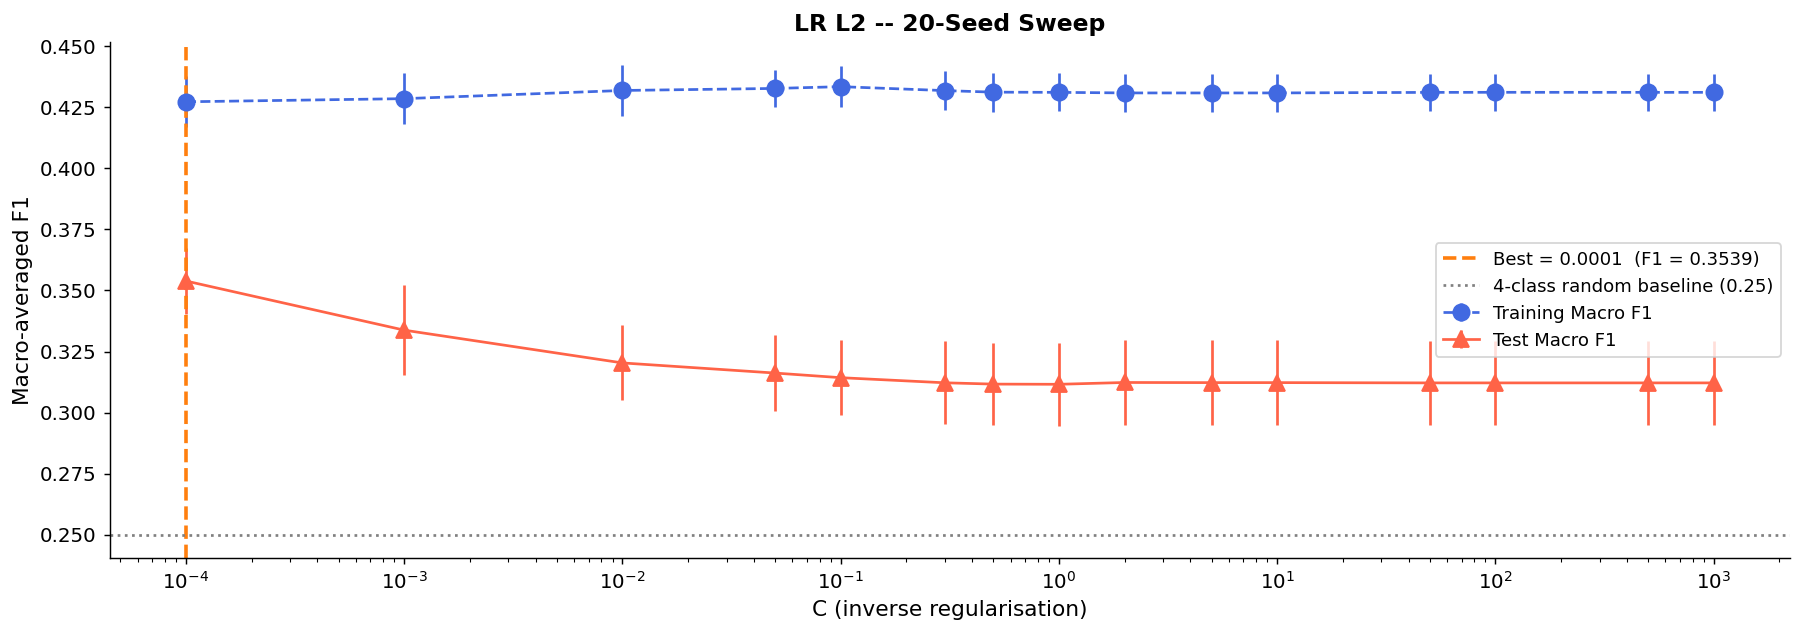

------------------------------------------------------------------
  LR L2 (C=0.0001)
  [20-seed sweep] Mean Test Macro F1 = 0.3539 +/- 0.0270
  Train F1 (default)   = 0.4475
  Test  F1 (default)   = 0.3592
  Test  F1 (thresholds (0.5, 0.3, 0.3, 0.2)) = 0.2706
  Test  Balanced Acc   = 0.3828
  Train-Test gap = 0.0883  ok

              precision    recall  f1-score   support

          T0       0.86      0.73      0.79       256
          T1       0.18      0.21      0.19        38
          T2       0.11      0.26      0.16        23
          T3       0.27      0.33      0.30         9

    accuracy                           0.62       326
   macro avg       0.36      0.38      0.36       326
weighted avg       0.71      0.62      0.66       326



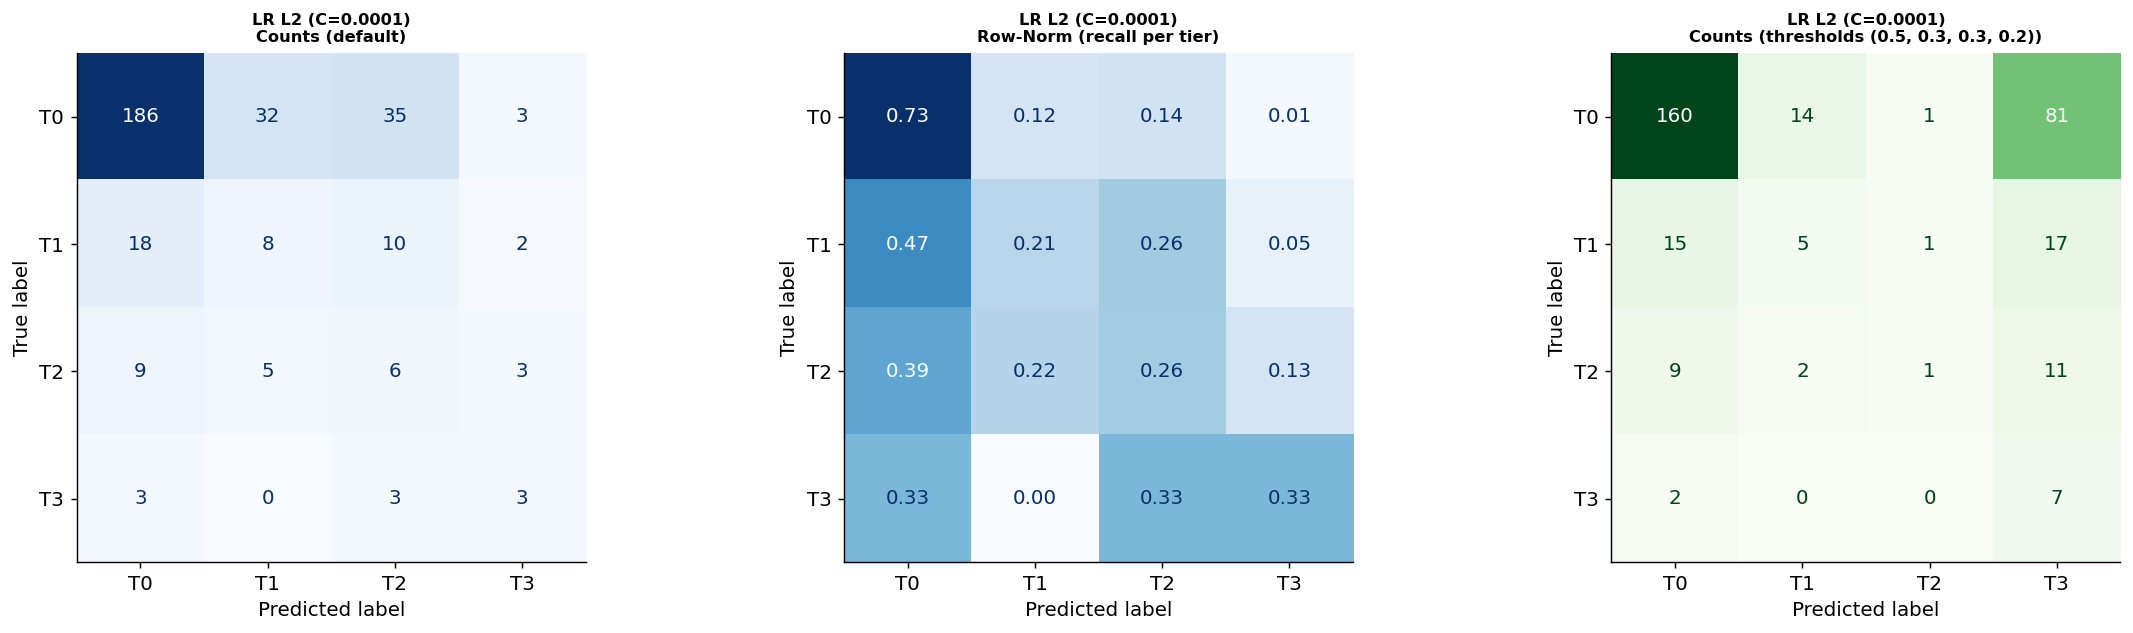

In [18]:
C_grid = [1e-4, 1e-3, 0.01, 0.05, 0.1, 0.3, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000]

lr2_tr_m, lr2_tr_s, lr2_te_m, lr2_te_s = sweep_1d(
    lambda C, seed: LogisticRegression(C=C, penalty="l2", class_weight="balanced",
                                        solver="lbfgs", max_iter=2000, random_state=seed),
    C_grid, X_full, y_full, smote_targets=SMOTE_TARGETS
)
best_C_lr2 = C_grid[np.argmax(lr2_te_m)]
lr2_sw_f1  = lr2_te_m[np.argmax(lr2_te_m)]
lr2_sw_std = lr2_te_s[np.argmax(lr2_te_m)]

plot_sweep(C_grid, lr2_tr_m, lr2_tr_s, lr2_te_m, lr2_te_s,
           "C (inverse regularisation)", "LR L2 -- 20-Seed Sweep",
           best_C_lr2, lr2_sw_f1, xscale="log")

lr2_final = LogisticRegression(C=best_C_lr2, penalty="l2", class_weight="balanced",
                                solver="lbfgs", max_iter=2000, random_state=42)
lr2_final.fit(X_train_smote, y_train_smote)

lr2_tr_f1, lr2_te_f1, lr2_th_f1, lr2_best_th = evaluate_model(
    f"LR L2 (C={best_C_lr2})", lr2_final,
    X_train_smote, y_train_smote, X_test_input, y_test_arr,
    lr2_sw_f1, lr2_sw_std)


### 8.3 Model 3 -- Logistic Regression (L1 / Lasso)

L1 drives PC coefficients to zero, revealing which components are truly informative. `solver='saga'` supports L1 multiclass.

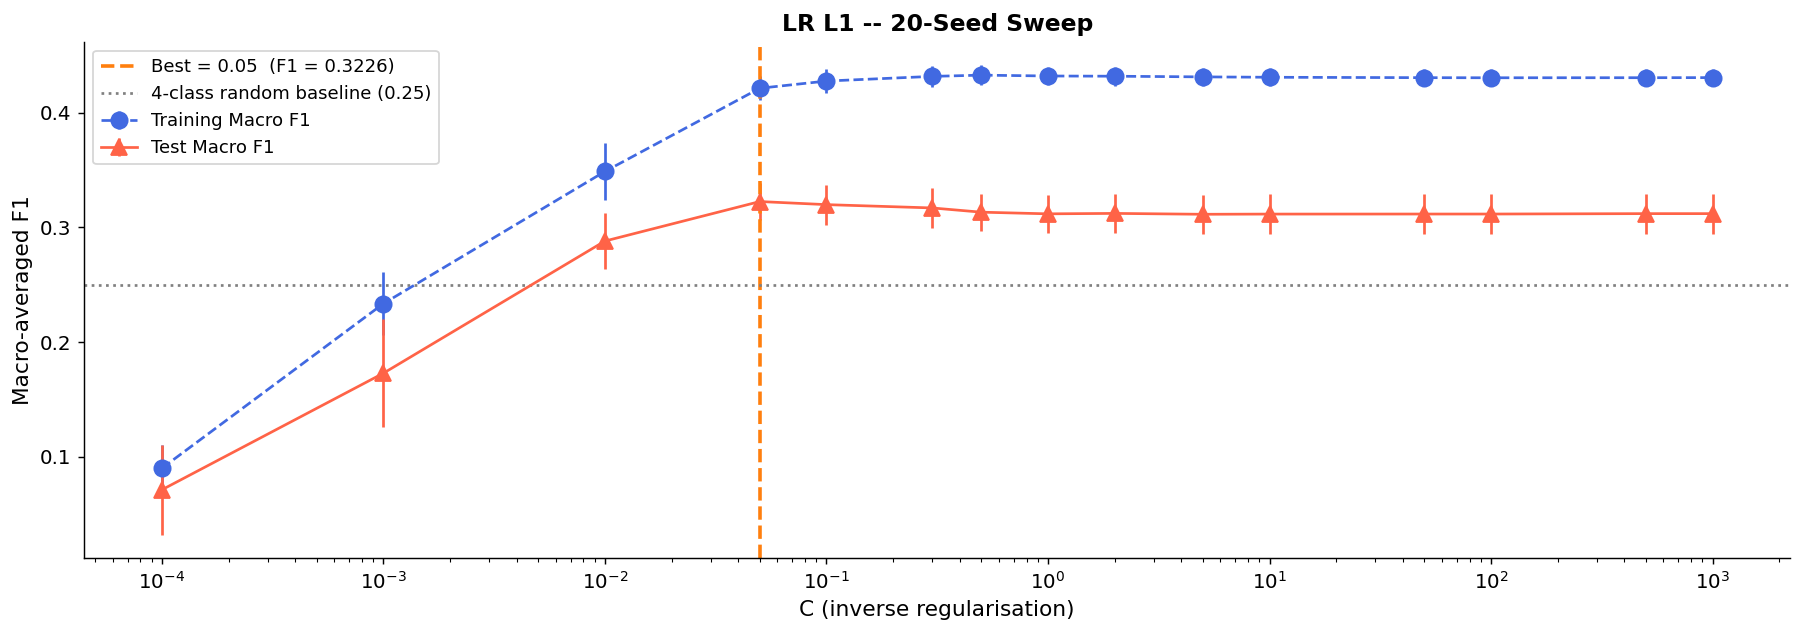

------------------------------------------------------------------
  LR L1 (C=0.05)
  [20-seed sweep] Mean Test Macro F1 = 0.3226 +/- 0.0322
  Train F1 (default)   = 0.4162
  Test  F1 (default)   = 0.2944
  Test  F1 (thresholds (0.5, 0.4, 0.35, 0.2)) = 0.2680
  Test  Balanced Acc   = 0.3357
  Train-Test gap = 0.1218  ok

              precision    recall  f1-score   support

          T0       0.88      0.60      0.71       256
          T1       0.13      0.13      0.13        38
          T2       0.09      0.39      0.14        23
          T3       0.17      0.22      0.19         9

    accuracy                           0.52       326
   macro avg       0.32      0.34      0.29       326
weighted avg       0.72      0.52      0.59       326



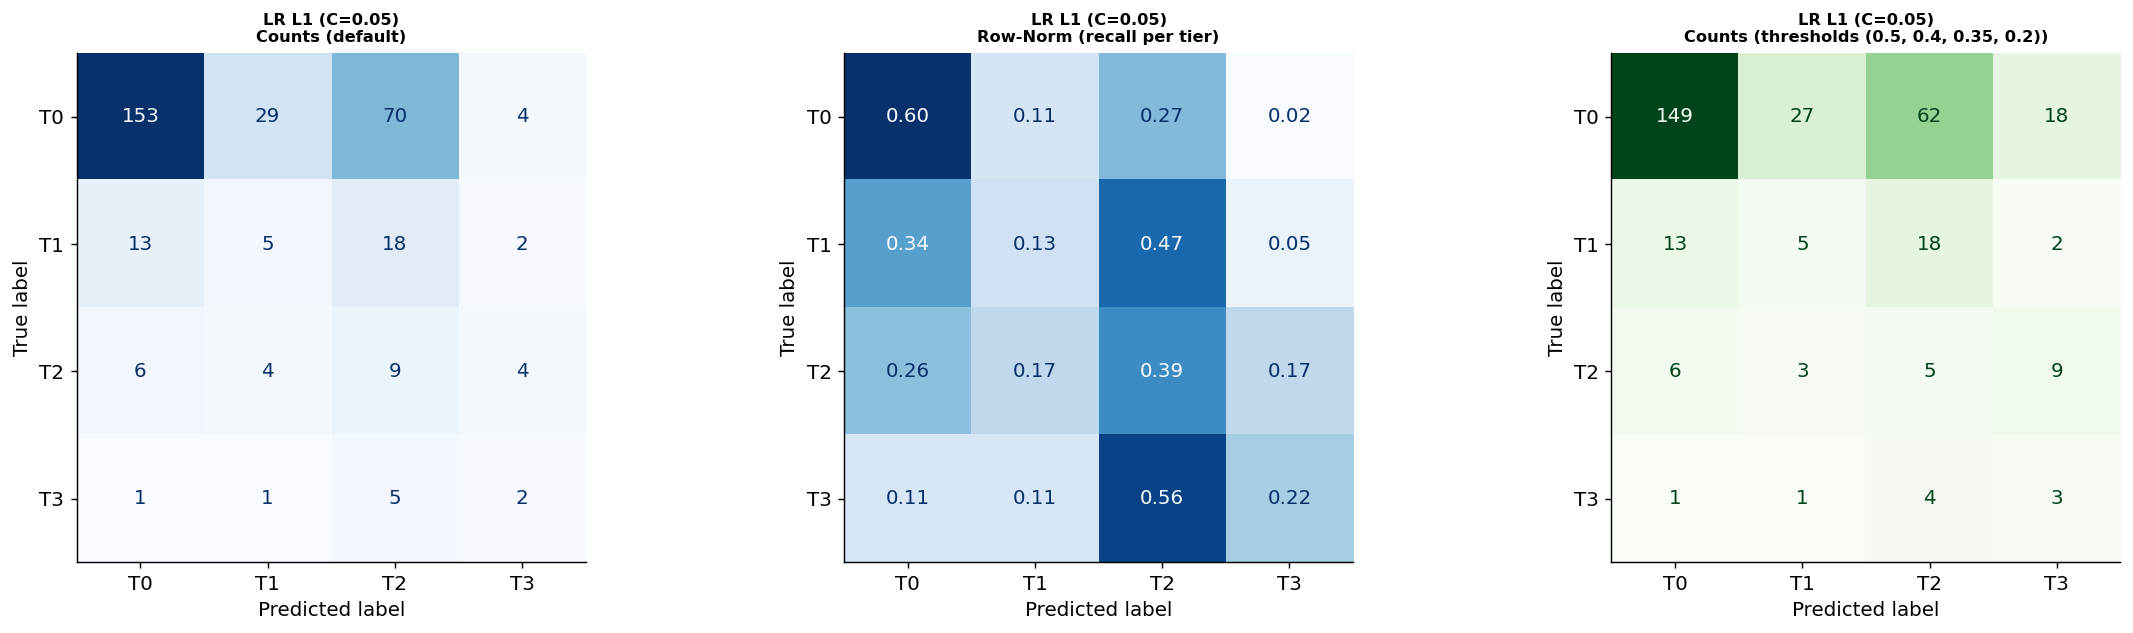

In [19]:
lr1_tr_m, lr1_tr_s, lr1_te_m, lr1_te_s = sweep_1d(
    lambda C, seed: LogisticRegression(C=C, penalty="l1", class_weight="balanced",
                                        solver="saga", max_iter=3000, random_state=seed),
    C_grid, X_full, y_full, smote_targets=SMOTE_TARGETS
)
best_C_lr1 = C_grid[np.argmax(lr1_te_m)]
lr1_sw_f1  = lr1_te_m[np.argmax(lr1_te_m)]
lr1_sw_std = lr1_te_s[np.argmax(lr1_te_m)]

plot_sweep(C_grid, lr1_tr_m, lr1_tr_s, lr1_te_m, lr1_te_s,
           "C (inverse regularisation)", "LR L1 -- 20-Seed Sweep",
           best_C_lr1, lr1_sw_f1, xscale="log")

lr1_final = LogisticRegression(C=best_C_lr1, penalty="l1", class_weight="balanced",
                                solver="saga", max_iter=3000, random_state=42)
lr1_final.fit(X_train_smote, y_train_smote)

lr1_tr_f1, lr1_te_f1, lr1_th_f1, lr1_best_th = evaluate_model(
    f"LR L1 (C={best_C_lr1})", lr1_final,
    X_train_smote, y_train_smote, X_test_input, y_test_arr,
    lr1_sw_f1, lr1_sw_std)


### 8.4 Model 4 -- Random Forest

Following **Notebook 4A**: scan `max_depth` 1-15 over 20 seeds. `class_weight='balanced_subsample'` further helps minority tiers.

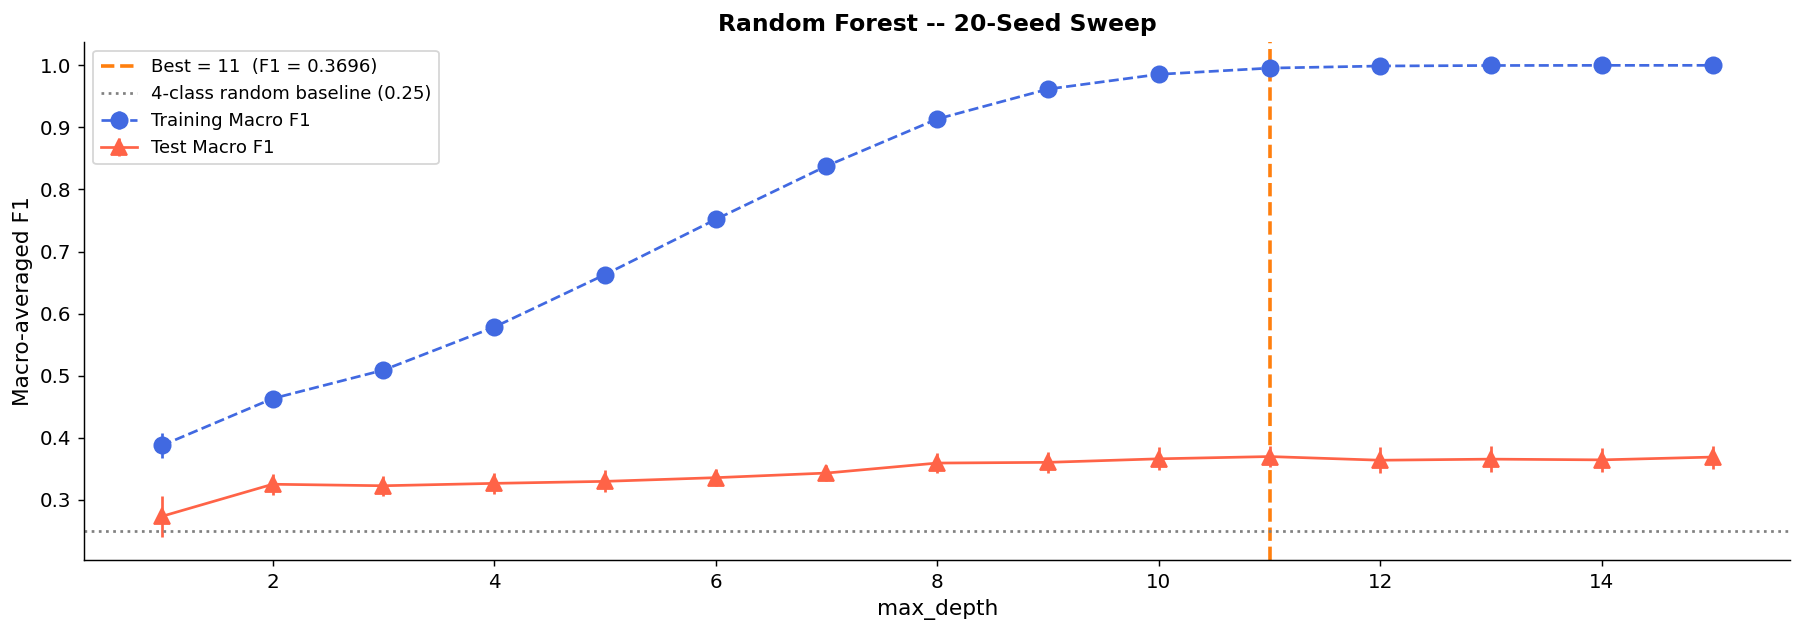

------------------------------------------------------------------
  RF (d=11)
  [20-seed sweep] Mean Test Macro F1 = 0.3696 +/- 0.0329
  Train F1 (default)   = 0.9970
  Test  F1 (default)   = 0.3130
  Test  F1 (thresholds (0.5, 0.3, 0.2, 0.2)) = 0.3329
  Test  Balanced Acc   = 0.3105
  Train-Test gap = 0.6840  !! overfit?

              precision    recall  f1-score   support

          T0       0.81      0.87      0.84       256
          T1       0.17      0.11      0.13        38
          T2       0.06      0.04      0.05        23
          T3       0.25      0.22      0.24         9

    accuracy                           0.71       326
   macro avg       0.32      0.31      0.31       326
weighted avg       0.66      0.71      0.68       326



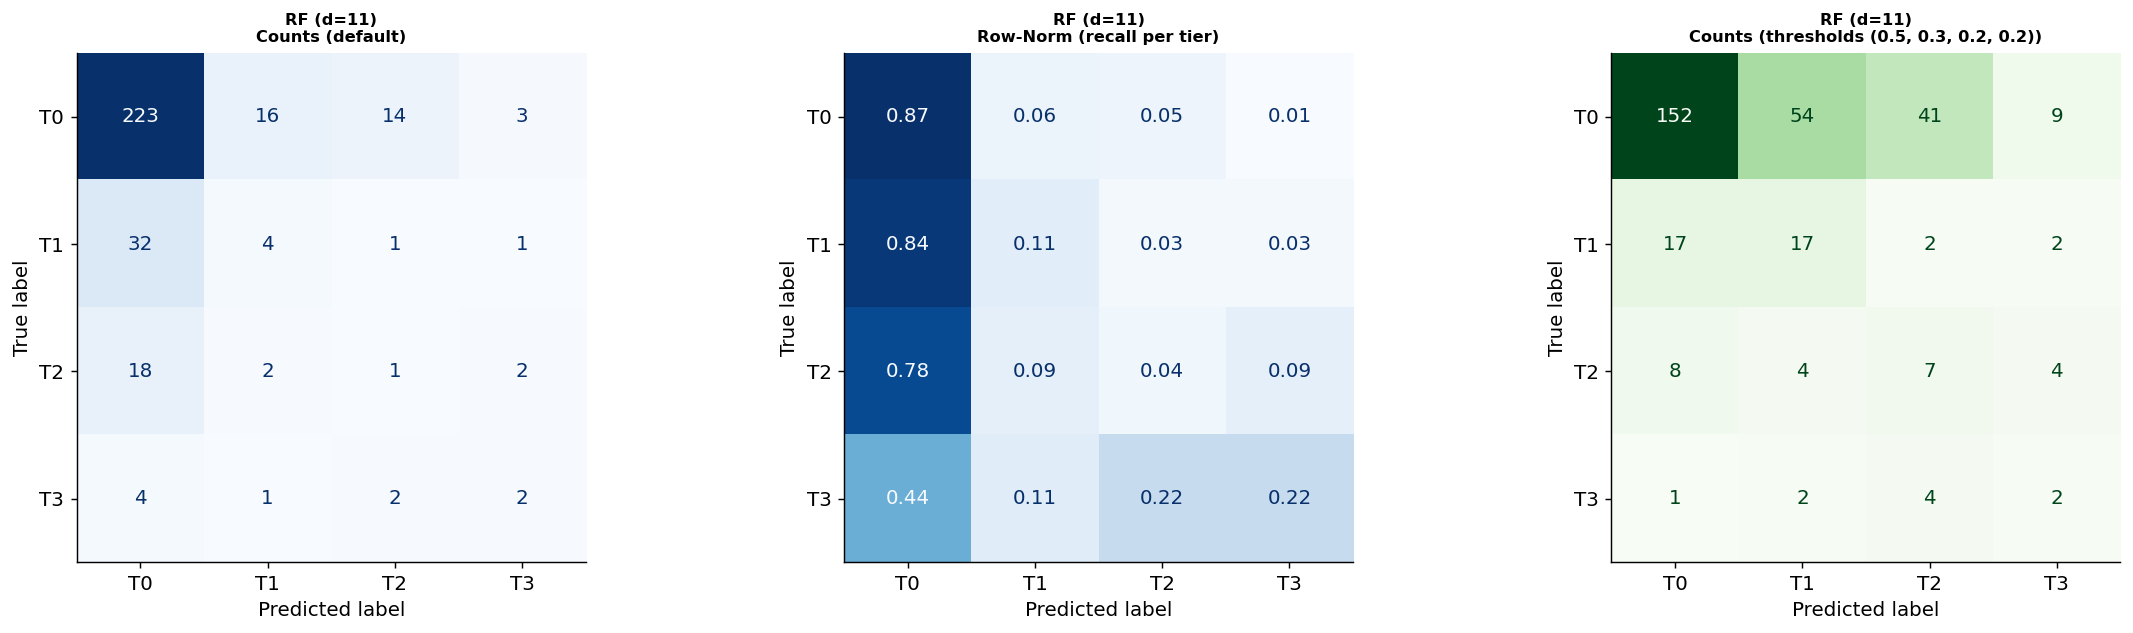

In [20]:
depths = list(range(1, 16))

rf_tr_m, rf_tr_s, rf_te_m, rf_te_s = sweep_1d(
    lambda d, seed: RandomForestClassifier(n_estimators=100, max_depth=d,
                                            class_weight="balanced_subsample",
                                            random_state=seed, n_jobs=-1),
    depths, X_full, y_full, smote_targets=SMOTE_TARGETS
)
best_rf_d  = depths[np.argmax(rf_te_m)]
rf_sw_f1   = rf_te_m[np.argmax(rf_te_m)]
rf_sw_std  = rf_te_s[np.argmax(rf_te_m)]

plot_sweep(depths, rf_tr_m, rf_tr_s, rf_te_m, rf_te_s,
           "max_depth", "Random Forest -- 20-Seed Sweep",
           best_rf_d, rf_sw_f1)

rf_final = RandomForestClassifier(n_estimators=200, max_depth=best_rf_d,
                                   class_weight="balanced_subsample",
                                   random_state=42, n_jobs=-1)
rf_final.fit(X_train_smote, y_train_smote)

rf_tr_f1, rf_te_f1, rf_th_f1, rf_best_th = evaluate_model(
    f"RF (d={best_rf_d})", rf_final,
    X_train_smote, y_train_smote, X_test_input, y_test_arr,
    rf_sw_f1, rf_sw_std)


### 8.5 Model 5 -- Gradient Boosted Trees (GBM)

2D grid search over `max_depth` x `learning_rate`, each with 20 seeds. `subsample=0.8` for stochastic boosting.

**Hyperparameter justification:**
- `max_depth in {1, 2, 3}`: shallow trees for boosting (Friedman 2001)
- `learning_rate in {0.05, 0.1, 0.2, 0.3}`: lower LR = better generalisation
- `n_estimators=100` during sweep, 200 for final model


In [21]:
depth_grid = [1, 2, 3]
lr_grid    = [0.05, 0.1, 0.2, 0.3]
grid_results = {}

for d in depth_grid:
    for lr in lr_grid:
        f1s = []
        for seed in range(1, 21):
            Xtr, Xte, ytr_, yte_ = train_test_split(
                X_full, y_full, test_size=0.20, random_state=seed, stratify=y_full)
            Xsm, ysm = hybrid_smote(Xtr, ytr_,
                {0: 500, 1: int((ytr_ == 1).sum()), 2: 150, 3: 150}, random_state=seed)
            clf = GradientBoostingClassifier(
                n_estimators=100, max_depth=d, learning_rate=lr,
                subsample=0.8, random_state=seed)
            clf.fit(Xsm, ysm)
            f1s.append(macro_f1(clf, Xte, yte_))
        grid_results[(d, lr)] = (np.mean(f1s), np.std(f1s))
        print(f"  d={d}, lr={lr:.2f}: F1={np.mean(f1s):.4f} +/- {np.std(f1s):.4f}")

best_g = max(grid_results, key=lambda k: grid_results[k][0])
best_gbm_d, best_gbm_lr = best_g
gbm_sw_f1, gbm_sw_std = grid_results[best_g]
print(f"\nBest: d={best_gbm_d}, lr={best_gbm_lr}, F1={gbm_sw_f1:.4f}")


  d=1, lr=0.05: F1=0.3411 +/- 0.0318
  d=1, lr=0.10: F1=0.3495 +/- 0.0444
  d=1, lr=0.20: F1=0.3412 +/- 0.0437
  d=1, lr=0.30: F1=0.3358 +/- 0.0440
  d=2, lr=0.05: F1=0.3420 +/- 0.0475
  d=2, lr=0.10: F1=0.3438 +/- 0.0495
  d=2, lr=0.20: F1=0.3482 +/- 0.0382
  d=2, lr=0.30: F1=0.3457 +/- 0.0364
  d=3, lr=0.05: F1=0.3427 +/- 0.0461
  d=3, lr=0.10: F1=0.3503 +/- 0.0379
  d=3, lr=0.20: F1=0.3449 +/- 0.0444
  d=3, lr=0.30: F1=0.3497 +/- 0.0395

Best: d=3, lr=0.1, F1=0.3503


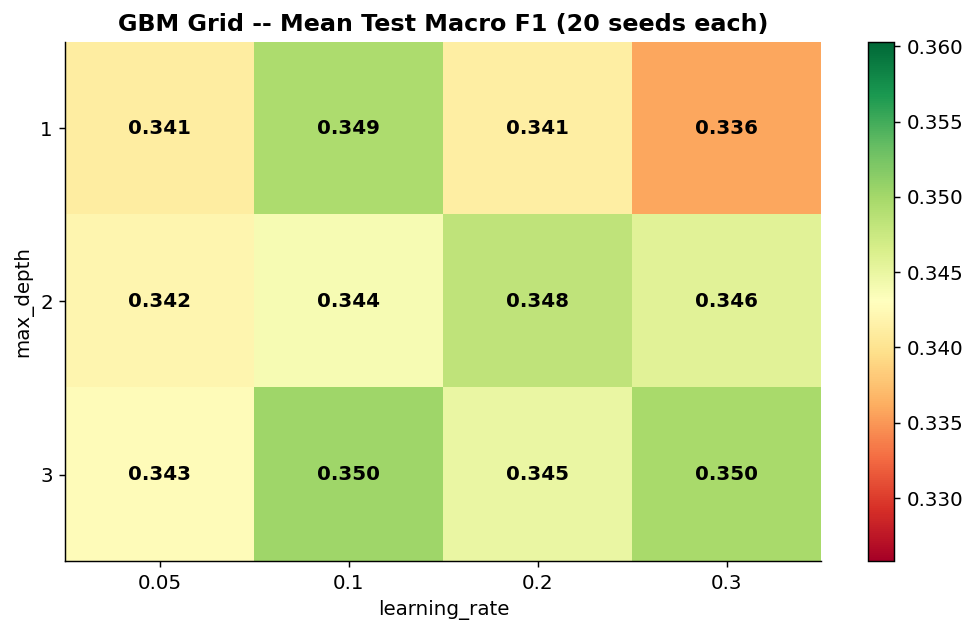

------------------------------------------------------------------
  GBM (d=3, lr=0.1)
  [20-seed sweep] Mean Test Macro F1 = 0.3503 +/- 0.0379
  Train F1 (default)   = 0.9959
  Test  F1 (default)   = 0.3192
  Test  F1 (thresholds (0.5, 0.4, 0.35, 0.18)) = 0.3132
  Test  Balanced Acc   = 0.3165
  Train-Test gap = 0.6767  !! overfit?

              precision    recall  f1-score   support

          T0       0.82      0.85      0.84       256
          T1       0.13      0.11      0.12        38
          T2       0.09      0.09      0.09        23
          T3       0.25      0.22      0.24         9

    accuracy                           0.69       326
   macro avg       0.32      0.32      0.32       326
weighted avg       0.67      0.69      0.68       326



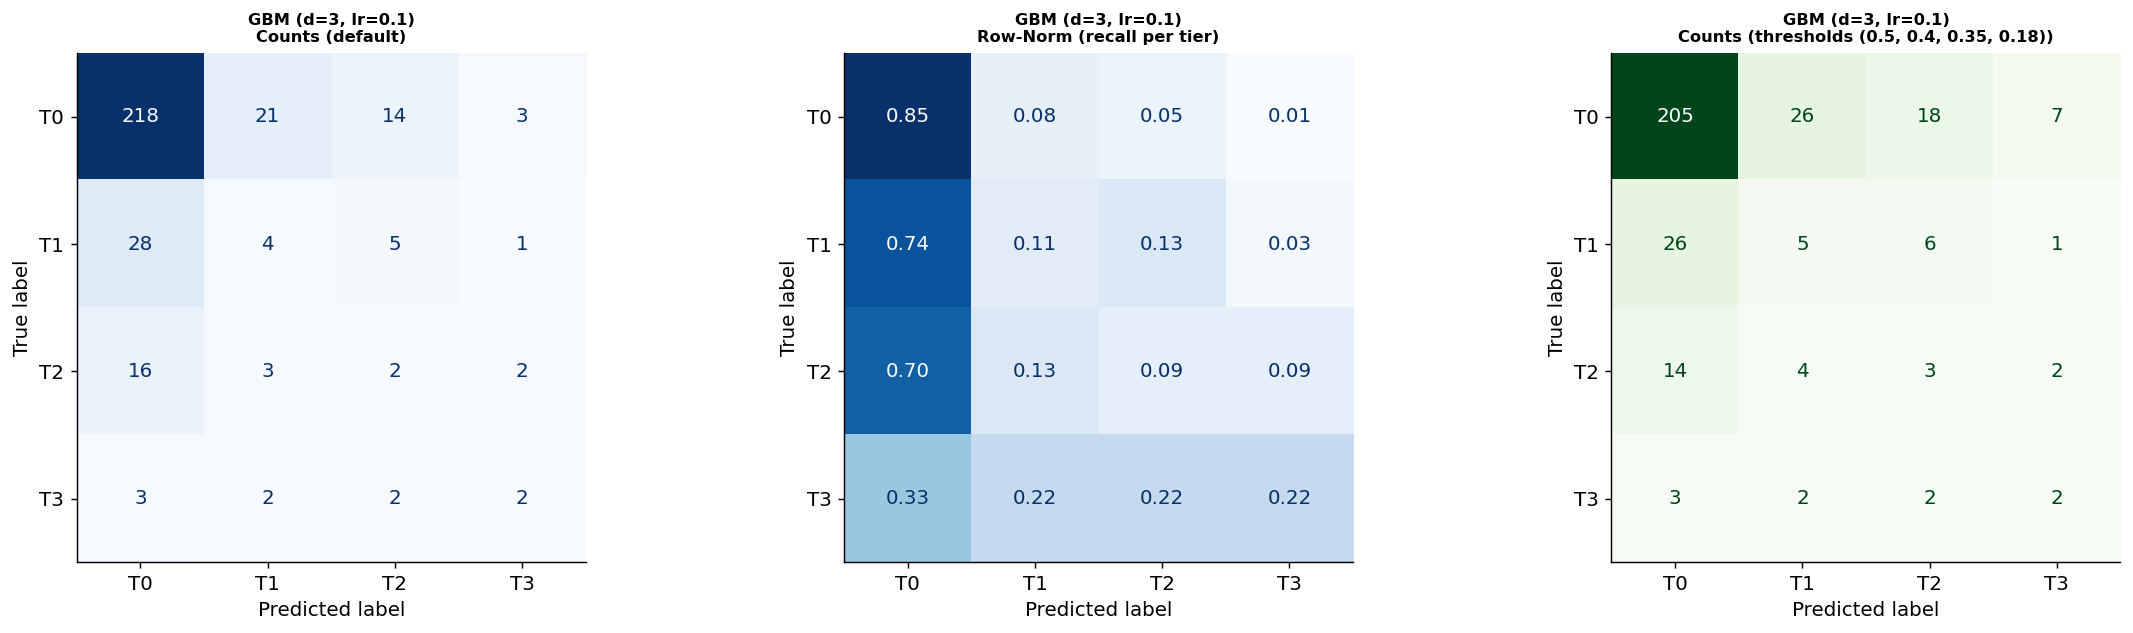

In [22]:
# ── GBM grid heatmap ──────────────────────────────────────────────────────
grid_means = np.array([[grid_results[(d, lr)][0] for lr in lr_grid] for d in depth_grid])
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(grid_means, cmap="RdYlGn", aspect="auto",
               vmin=grid_means.min() - 0.01, vmax=grid_means.max() + 0.01)
ax.set_xticks(range(len(lr_grid))); ax.set_xticklabels([str(l) for l in lr_grid])
ax.set_yticks(range(len(depth_grid))); ax.set_yticklabels([str(d) for d in depth_grid])
ax.set_xlabel("learning_rate"); ax.set_ylabel("max_depth")
ax.set_title("GBM Grid -- Mean Test Macro F1 (20 seeds each)", fontweight="bold")
for i in range(len(depth_grid)):
    for j in range(len(lr_grid)):
        ax.text(j, i, f"{grid_means[i, j]:.3f}", ha="center", va="center",
                fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# ── Train final GBM ──────────────────────────────────────────────────────
gbm_final = GradientBoostingClassifier(
    n_estimators=200, max_depth=best_gbm_d, learning_rate=best_gbm_lr,
    subsample=0.8, random_state=42)
gbm_final.fit(X_train_smote, y_train_smote)

gbm_tr_f1, gbm_te_f1, gbm_th_f1, gbm_best_th = evaluate_model(
    f"GBM (d={best_gbm_d}, lr={best_gbm_lr})", gbm_final,
    X_train_smote, y_train_smote, X_test_input, y_test_arr,
    gbm_sw_f1, gbm_sw_std)


### 8.6 Stacking Classifier

Per professor's instruction: stack RF + GBM + LR + kNN with a balanced LR meta-learner. `cv=5` out-of-fold predictions prevent overfitting.


Stacking classifier trained.
------------------------------------------------------------------
  Stack (RF+GBM+LR+kNN->LR)
  Train F1 (default)   = 0.9597
  Test  F1 (default)   = 0.3211
  Test  F1 (thresholds (0.5, 0.45, 0.35, 0.2)) = 0.3049
  Test  Balanced Acc   = 0.3607
  Train-Test gap = 0.6386  !! overfit?

              precision    recall  f1-score   support

          T0       0.85      0.58      0.69       256
          T1       0.15      0.42      0.22        38
          T2       0.16      0.22      0.18        23
          T3       0.17      0.22      0.19         9

    accuracy                           0.53       326
   macro avg       0.33      0.36      0.32       326
weighted avg       0.70      0.53      0.59       326



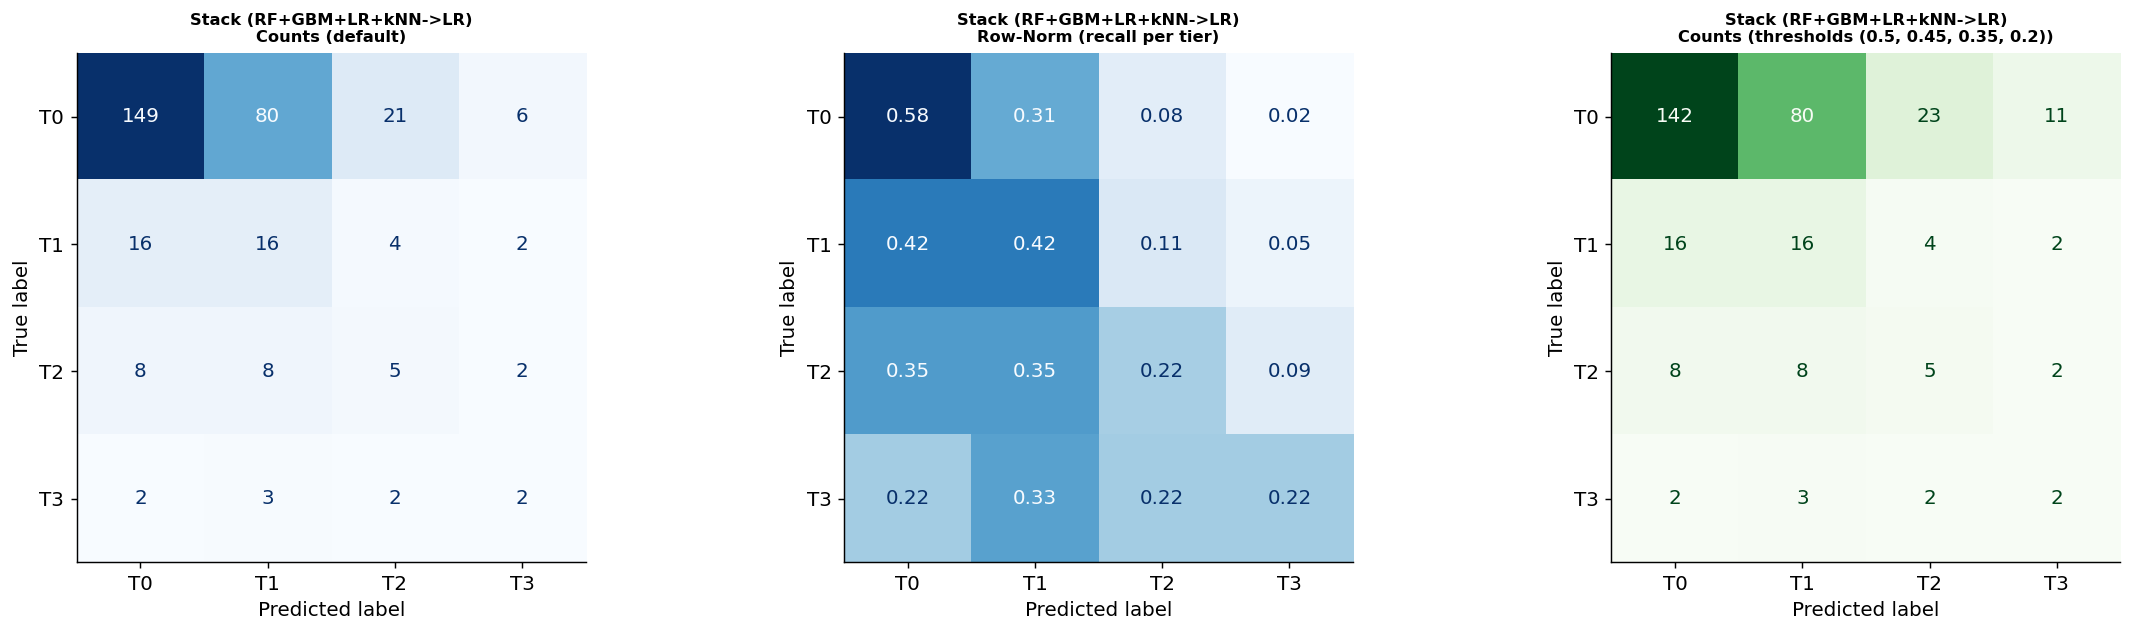

In [23]:
stack_clf = StackingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=200, max_depth=best_rf_d,
                                        class_weight="balanced_subsample",
                                        random_state=42, n_jobs=-1)),
        ("gbm", GradientBoostingClassifier(n_estimators=100, max_depth=best_gbm_d,
                                            learning_rate=best_gbm_lr,
                                            subsample=0.8, random_state=42)),
        ("lr2", LogisticRegression(C=best_C_lr2, class_weight="balanced",
                                    solver="lbfgs", max_iter=2000, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")),
    ],
    final_estimator=LogisticRegression(C=0.5, class_weight="balanced",
                                        solver="lbfgs", max_iter=2000, random_state=42),
    stack_method="predict_proba", cv=5, n_jobs=-1
)
stack_clf.fit(X_train_smote, y_train_smote)
print("Stacking classifier trained.")

stk_tr_f1, stk_te_f1, stk_th_f1, stk_best_th = evaluate_model(
    "Stack (RF+GBM+LR+kNN->LR)", stack_clf,
    X_train_smote, y_train_smote, X_test_input, y_test_arr,
    sw_f1=0.0, sw_std=0.0)


---
## §9. Model Comparison

In [24]:
ALL_MODELS  = [knn_final, lr2_final, lr1_final, rf_final, gbm_final, stack_clf]
ALL_NAMES   = [f"kNN\nk={best_k}", f"LR L2\nC={best_C_lr2}",
               f"LR L1\nC={best_C_lr1}", f"RF\nd={best_rf_d}",
               f"GBM\nd={best_gbm_d}", "Stack\n(RF+GBM\n+LR+kNN)"]
ALL_SW_F1S  = [knn_sw_f1, lr2_sw_f1, lr1_sw_f1, rf_sw_f1, gbm_sw_f1, stk_te_f1]
ALL_SW_STDS = [knn_sw_std, lr2_sw_std, lr1_sw_std, rf_sw_std, gbm_sw_std, 0.0]
ALL_TR_F1S  = [knn_tr_f1, lr2_tr_f1, lr1_tr_f1, rf_tr_f1, gbm_tr_f1, stk_tr_f1]
ALL_TE_F1S  = [knn_te_f1, lr2_te_f1, lr1_te_f1, rf_te_f1, gbm_te_f1, stk_te_f1]
ALL_TH_F1S  = [knn_th_f1, lr2_th_f1, lr1_th_f1, rf_th_f1, gbm_th_f1, stk_th_f1]
ALL_BEST_TH = [knn_best_th, lr2_best_th, lr1_best_th, rf_best_th, gbm_best_th, stk_best_th]

results = pd.DataFrame({
    "Model": [n.replace("\n", " ") for n in ALL_NAMES],
    "Sweep F1": ALL_SW_F1S, "Sweep Std": ALL_SW_STDS,
    "Train F1": ALL_TR_F1S, "Test F1": ALL_TE_F1S,
    "Test F1 (tuned)": ALL_TH_F1S,
}).round(4)
print(results.to_string(index=False))

best_idx = int(np.argmax(ALL_TH_F1S))
print(f"\n* Best model (by threshold-tuned F1): {ALL_NAMES[best_idx].replace(chr(10), ' ')}")
print(f"  Test Macro F1 (tuned) = {ALL_TH_F1S[best_idx]:.4f}")


                 Model  Sweep F1  Sweep Std  Train F1  Test F1  Test F1 (tuned)
               kNN k=2    0.3278     0.0345    0.8201   0.2965           0.2525
        LR L2 C=0.0001    0.3539     0.0270    0.4475   0.3592           0.2706
          LR L1 C=0.05    0.3226     0.0322    0.4162   0.2944           0.2680
               RF d=11    0.3696     0.0329    0.9970   0.3130           0.3329
               GBM d=3    0.3503     0.0379    0.9959   0.3192           0.3132
Stack (RF+GBM +LR+kNN)    0.3211     0.0000    0.9597   0.3211           0.3049

* Best model (by threshold-tuned F1): RF d=11
  Test Macro F1 (tuned) = 0.3329


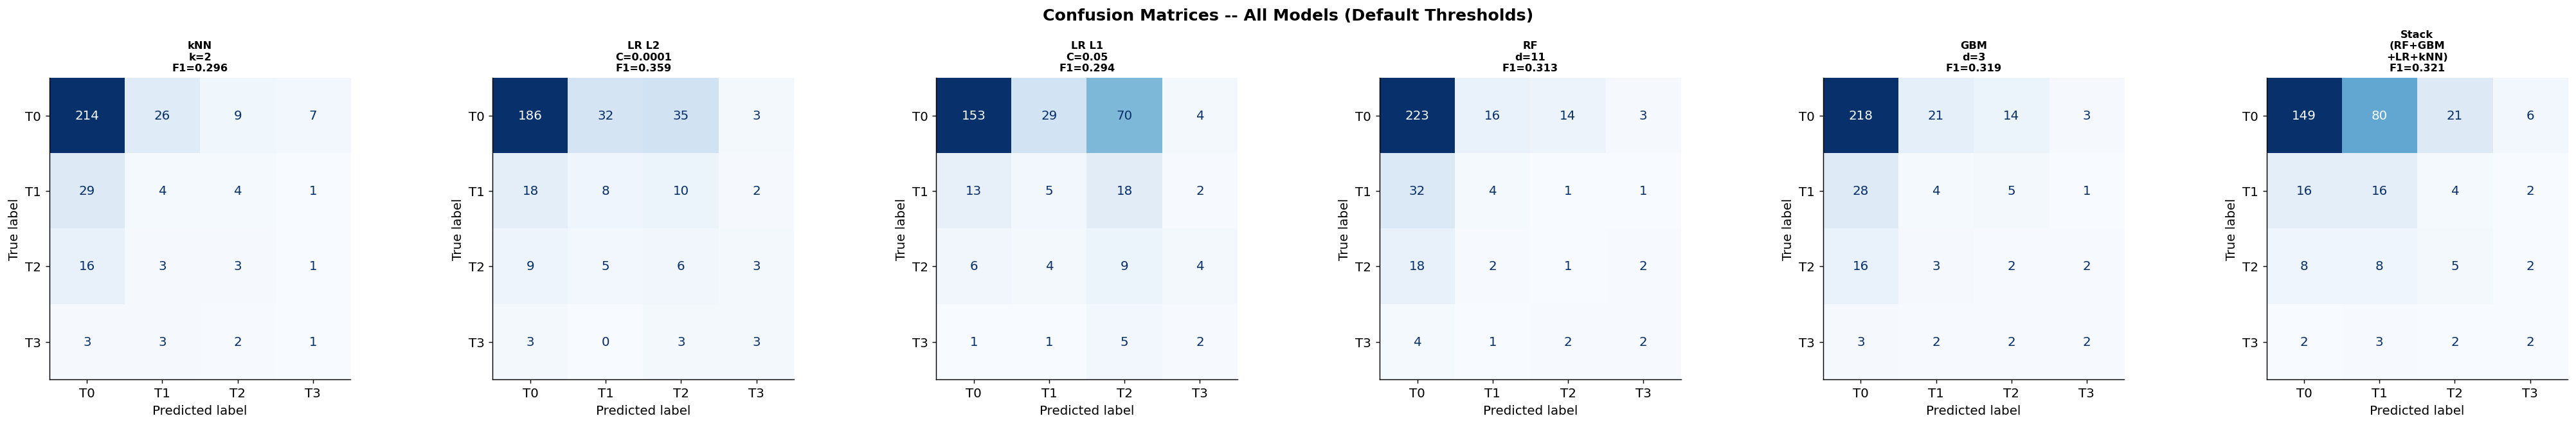

In [25]:
# ── All confusion matrices side-by-side ───────────────────────────────────
fig, axes = plt.subplots(1, len(ALL_MODELS), figsize=(5 * len(ALL_MODELS) + 2, 5))
for ax, model, name in zip(axes, ALL_MODELS, ALL_NAMES):
    y_pred = model.predict(X_test_input)
    cm = confusion_matrix(y_test_arr, y_pred)
    f1 = macro_f1(model, X_test_input, y_test_arr)
    ConfusionMatrixDisplay(cm, display_labels=["T0", "T1", "T2", "T3"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nF1={f1:.3f}", fontsize=9, fontweight="bold")
fig.suptitle("Confusion Matrices -- All Models (Default Thresholds)", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.show()


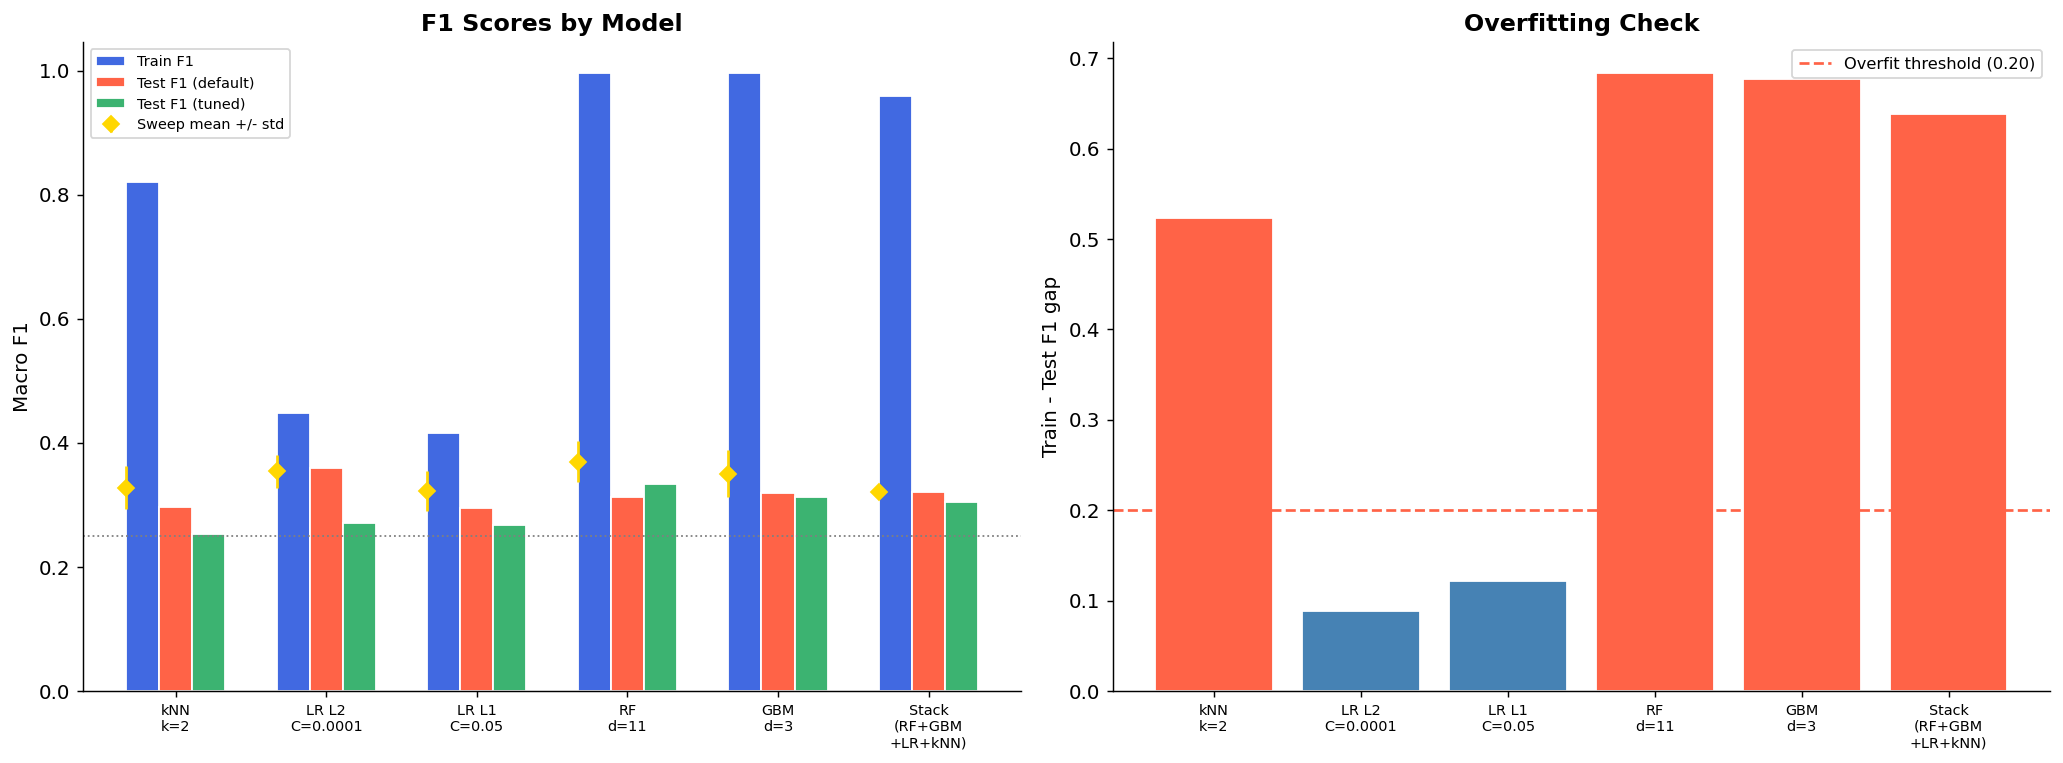

In [26]:
# ── Bar chart: Train vs Test vs Threshold-tuned F1 ────────────────────────
x = np.arange(len(ALL_NAMES)); w = 0.22
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x - w, ALL_TR_F1S, w, label="Train F1", color="royalblue", edgecolor="white")
axes[0].bar(x, ALL_TE_F1S, w, label="Test F1 (default)", color="tomato", edgecolor="white")
axes[0].bar(x + w, ALL_TH_F1S, w, label="Test F1 (tuned)", color="mediumseagreen", edgecolor="white")
axes[0].errorbar(x - w * 1.5, ALL_SW_F1S, yerr=ALL_SW_STDS, fmt="D", color="gold",
                 markersize=6, label="Sweep mean +/- std", zorder=5)
axes[0].set_xticks(x); axes[0].set_xticklabels(ALL_NAMES, fontsize=8)
axes[0].set_ylabel("Macro F1"); axes[0].set_title("F1 Scores by Model", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].axhline(0.25, color="grey", ls=":", lw=1)

gaps = [tr - te for tr, te in zip(ALL_TR_F1S, ALL_TE_F1S)]
colours = ["tomato" if g > 0.2 else "steelblue" for g in gaps]
axes[1].bar(x, gaps, color=colours, edgecolor="white")
axes[1].axhline(0.20, color="tomato", ls="--", lw=1.5, label="Overfit threshold (0.20)")
axes[1].set_xticks(x); axes[1].set_xticklabels(ALL_NAMES, fontsize=8)
axes[1].set_ylabel("Train - Test F1 gap"); axes[1].set_title("Overfitting Check", fontweight="bold")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## §10. Feature / PC Importance

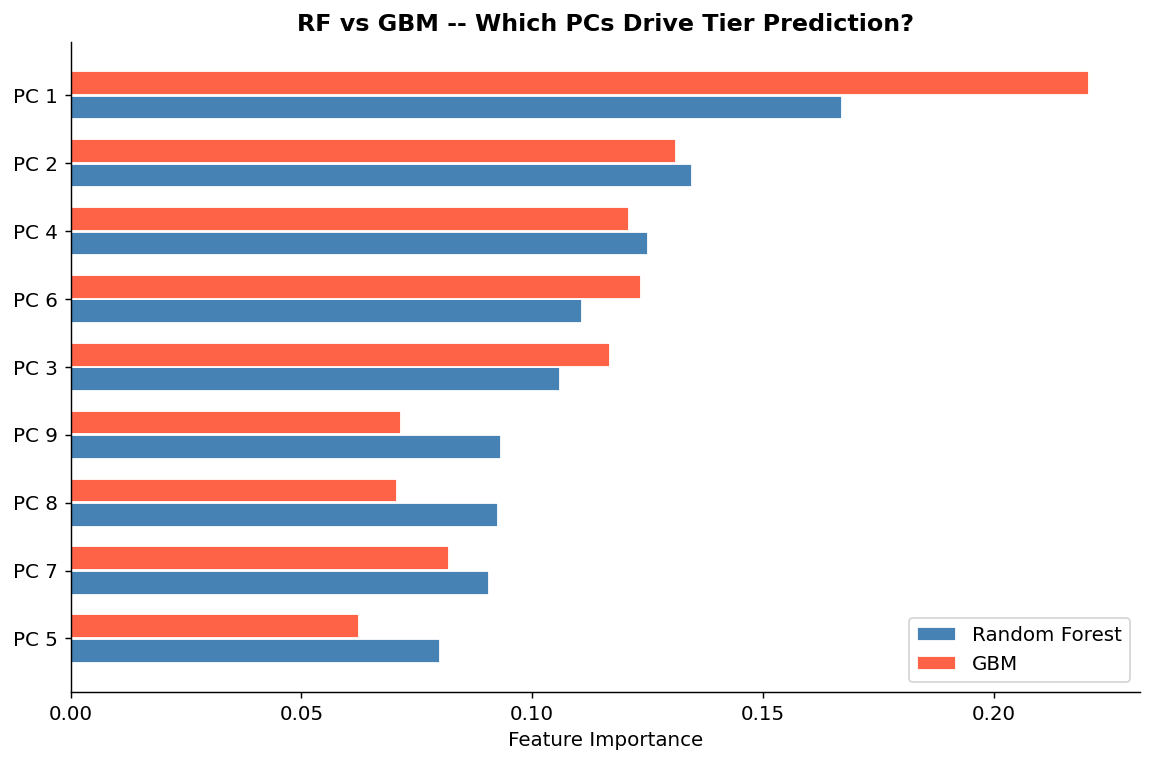

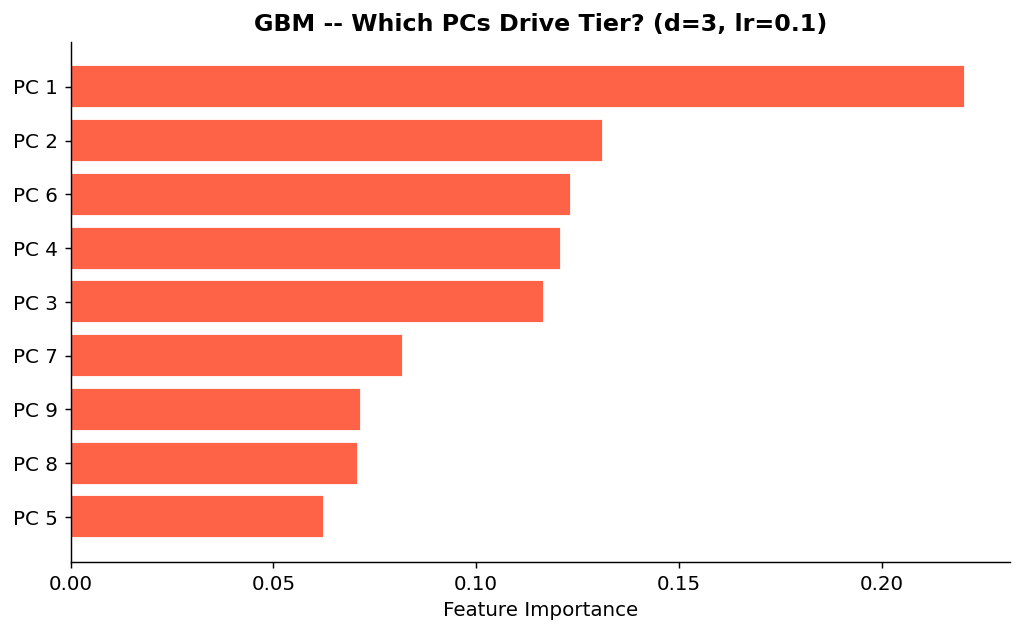

In [27]:
fi_df = pd.DataFrame({
    "RF": rf_final.feature_importances_,
    "GBM": gbm_final.feature_importances_
}, index=pc_labels).sort_values("RF")

xi = np.arange(n_components)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(xi - 0.18, fi_df["RF"], 0.35, label="Random Forest", color="steelblue", edgecolor="white")
ax.barh(xi + 0.18, fi_df["GBM"], 0.35, label="GBM", color="tomato", edgecolor="white")
ax.set_yticks(xi); ax.set_yticklabels(fi_df.index)
ax.set_xlabel("Feature Importance")
ax.set_title("RF vs GBM -- Which PCs Drive Tier Prediction?", fontweight="bold")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

fi_gbm = gbm_final.feature_importances_
si = fi_gbm.argsort()
fig = plt.figure(figsize=(8, 5))
plt.barh(np.array(pc_labels)[si], fi_gbm[si], color="tomato", edgecolor="white")
plt.xlabel("Feature Importance")
plt.title(f"GBM -- Which PCs Drive Tier? (d={best_gbm_d}, lr={best_gbm_lr})", fontweight="bold")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


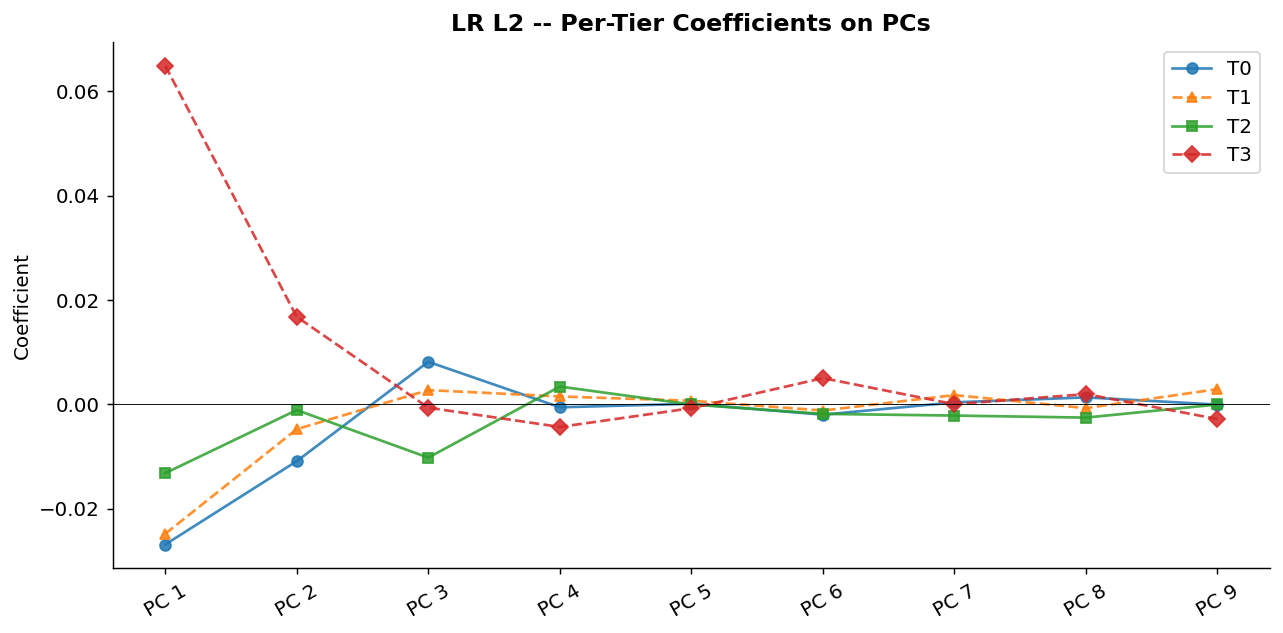

In [28]:
# ── LR L2 coefficient plot per tier ───────────────────────────────────────
fig = plt.figure(figsize=(10, 5))
for i, (tname, mk) in enumerate(zip(["T0", "T1", "T2", "T3"], ["-o", "--^", "-s", "--D"])):
    plt.plot(lr2_final.coef_[i], mk, label=tname, alpha=0.85)
plt.xticks(range(n_components), pc_labels, rotation=30)
plt.axhline(0, color="black", lw=0.5)
plt.ylabel("Coefficient")
plt.title("LR L2 -- Per-Tier Coefficients on PCs", fontweight="bold")
plt.legend()
plt.tight_layout(); plt.show()


---
## §11. Underserved LGU Identification

Using the best model (by threshold-tuned F1), we predict the tier for **all 1,629 LGUs** and identify those where the predicted tier exceeds the actual tier -- these are the "underserved" LGUs.

**Expected Tier** is a continuous score: E[tier] = sum over t of t * P(T=t)


In [29]:
best_idx_u = int(np.argmax(ALL_TH_F1S))
best_clf    = ALL_MODELS[best_idx_u]
best_th_u   = ALL_BEST_TH[best_idx_u]

# Scale full dataset with the SAME scaler fit on training set
X_all_sc = scaler.transform(X_imp)
# Apply PCA (using the SAME pca object fit on training data)
X_all_pca = pca.transform(X_all_sc)

pred_all  = predict_with_thresholds(best_clf, X_all_pca, best_th_u)
proba_all = best_clf.predict_proba(X_all_pca)

meta_out = df_raw.copy()
meta_out["tier"]          = make_tier(y_raw).values
meta_out["pred_tier"]     = pred_all
meta_out["tier_gap"]      = pred_all - meta_out["tier"].values
meta_out["expected_tier"] = (proba_all * np.array([0, 1, 2, 3])).sum(axis=1)

print("Tier gap (predicted - actual) distribution:")
print(meta_out["tier_gap"].value_counts().sort_index())
print()

underserved  = meta_out[meta_out["tier_gap"] > 0].sort_values("expected_tier", ascending=False)
appropriate  = meta_out[meta_out["tier_gap"] == 0]
oversupplied = meta_out[meta_out["tier_gap"] < 0]

print(f"Underserved  (pred > actual): {len(underserved):>4} LGUs  <- priority for new hospitals")
print(f"Appropriate  (pred = actual): {len(appropriate):>4} LGUs")
print(f"Oversupplied (pred < actual): {len(oversupplied):>4} LGUs")


Tier gap (predicted - actual) distribution:
tier_gap
-3       1
-2      10
-1      25
 0    1170
 1     189
 2     187
 3      47
Name: count, dtype: int64

Underserved  (pred > actual):  423 LGUs  <- priority for new hospitals
Appropriate  (pred = actual): 1170 LGUs
Oversupplied (pred < actual):   36 LGUs


In [30]:
us = underserved[["city_municipality", "region", "tier", "pred_tier",
                   "tier_gap", "expected_tier", "poverty_incidence_2023_pct"]].copy()
us.columns = ["LGU", "Region", "Actual", "Predicted", "Gap", "Exp. Tier", "Poverty 2023 (%)"]
us["Exp. Tier"] = us["Exp. Tier"].round(3)
us["Poverty 2023 (%)"] = us["Poverty 2023 (%)"].round(1)

print(f"UNDERSERVED LGUs ({len(us)} total, sorted by Expected Tier descending):")
print(us.head(30).to_string(index=False))

us.to_excel("underserved_lgus.xlsx", index=False)
print(f"\nExported -> underserved_lgus.xlsx  ({len(us)} LGUs)")


UNDERSERVED LGUs (423 total, sorted by Expected Tier descending):
               LGU                                 Region  Actual  Predicted  Gap  Exp. Tier  Poverty 2023 (%)
 CITY OF SAN PABLO               REGION IV-A (CALABARZON)       0          3    3      2.345               9.1
               BAY               REGION IV-A (CALABARZON)       0          3    3      2.301               7.3
            APALIT             REGION III (CENTRAL LUZON)       0          2    2      2.246               8.1
      CITY OF LIPA               REGION IV-A (CALABARZON)       2          3    1      2.031               5.0
     CITY OF GAPAN             REGION III (CENTRAL LUZON)       0          3    3      1.976              14.0
           DOLORES CORDILLERA ADMINISTRATIVE REGION (CAR)       0          3    3      1.910               7.9
          CAMILING             REGION III (CENTRAL LUZON)       0          3    3      1.872               9.6
          MAGALANG             REGION III (CEN

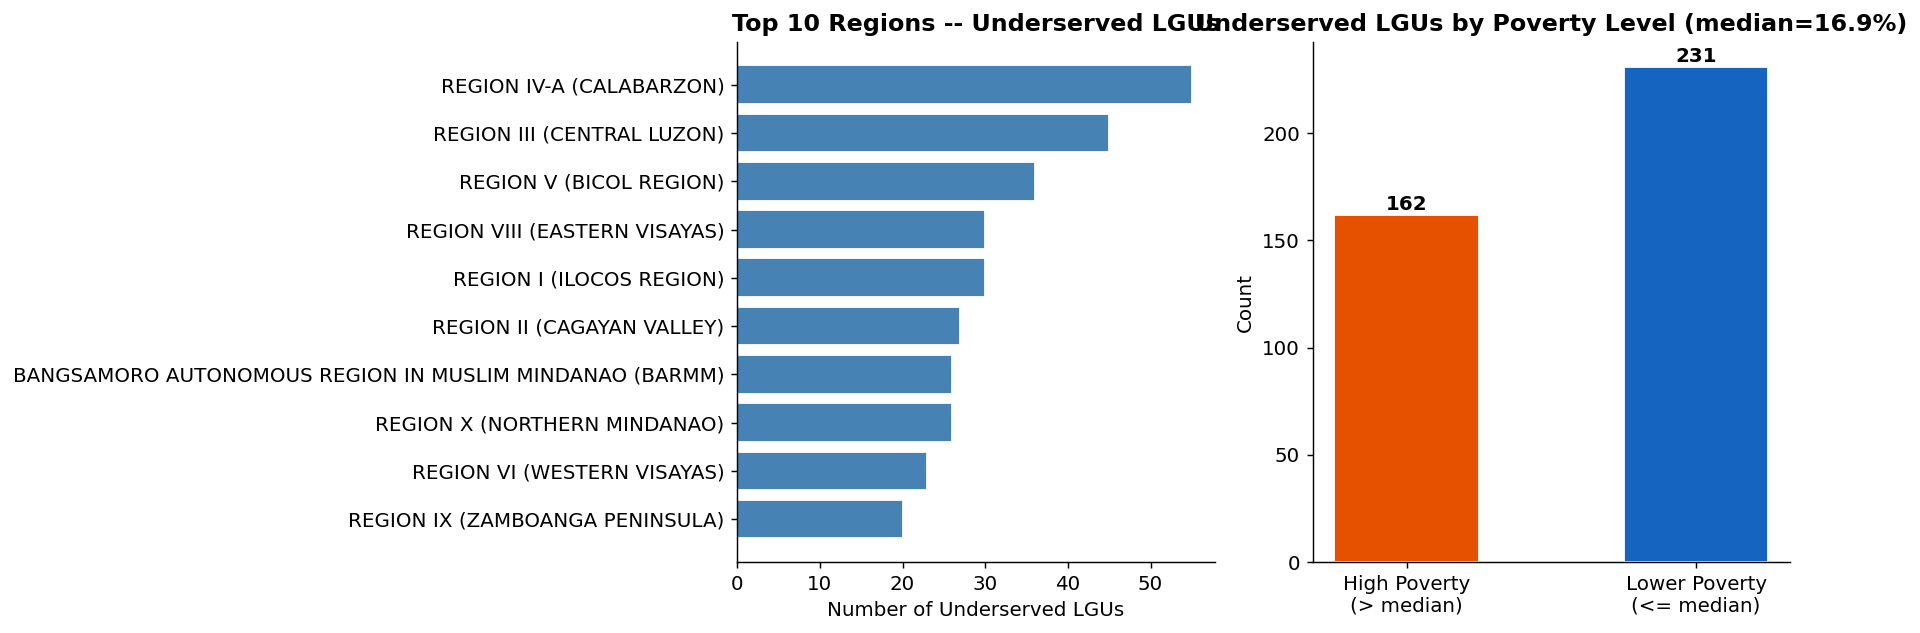

High-poverty underserved: 162 LGUs (priority for equity-focused intervention)
Lower-poverty underserved: 231 LGUs


In [31]:
pov_median = meta_out["poverty_incidence_2023_pct"].median()
eq_prio  = underserved[underserved["poverty_incidence_2023_pct"] > pov_median]
sup_prio = underserved[underserved["poverty_incidence_2023_pct"] <= pov_median]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_counts = underserved["region"].value_counts().head(10)
axes[0].barh(region_counts.index[::-1], region_counts.values[::-1],
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Number of Underserved LGUs")
axes[0].set_title("Top 10 Regions -- Underserved LGUs", fontweight="bold")

axes[1].bar(["High Poverty\n(> median)", "Lower Poverty\n(<= median)"],
            [len(eq_prio), len(sup_prio)],
            color=["#E65100", "#1565C0"], edgecolor="white", width=0.5)
for i, cnt in enumerate([len(eq_prio), len(sup_prio)]):
    axes[1].text(i, cnt + 2, str(cnt), ha="center", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Underserved LGUs by Poverty Level (median={pov_median:.1f}%)", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"High-poverty underserved: {len(eq_prio)} LGUs (priority for equity-focused intervention)")
print(f"Lower-poverty underserved: {len(sup_prio)} LGUs")


---
## §12. Equity Analysis -- Poverty x Hospital Tier

Kruskal-Wallis (poverty ~ tier): H=45.84, p=6.13e-10
Mann-Whitney (T0 > T3 poverty):  p=1.51e-07
  Tier 0: mean=20.5%  median=18.3%  n=1207
  Tier 1: mean=18.2%  median=13.8%  n=199
  Tier 2: mean=15.9%  median=13.3%  n=97
  Tier 3: mean=10.7%  median=8.3%  n=33


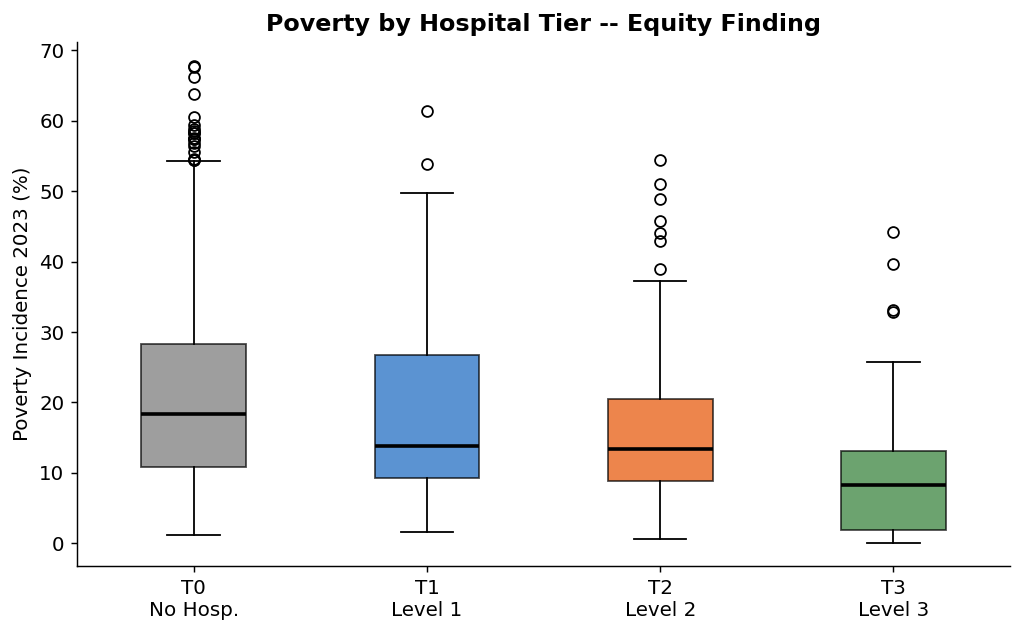


Conclusion: Tier 0 LGUs (no hospital) have significantly higher poverty
than Tier 3 LGUs (tertiary hospital), confirming an equity gap in hospital access.


In [32]:
pov_by_tier = [meta_out[meta_out["tier"] == t]["poverty_incidence_2023_pct"].dropna().values
               for t in range(4)]
stat_kw, p_kw = stats.kruskal(*pov_by_tier)
stat_mw, p_mw = stats.mannwhitneyu(pov_by_tier[0], pov_by_tier[3], alternative="greater")

print(f"Kruskal-Wallis (poverty ~ tier): H={stat_kw:.2f}, p={p_kw:.2e}")
print(f"Mann-Whitney (T0 > T3 poverty):  p={p_mw:.2e}")
for t, vals in enumerate(pov_by_tier):
    print(f"  Tier {t}: mean={vals.mean():.1f}%  median={np.median(vals):.1f}%  n={len(vals)}")

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(pov_by_tier, labels=TIER_LBLS, patch_artist=True,
                medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], TIER_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel("Poverty Incidence 2023 (%)")
ax.set_title("Poverty by Hospital Tier -- Equity Finding", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"\nConclusion: Tier 0 LGUs (no hospital) have significantly higher poverty")
print(f"than Tier 3 LGUs (tertiary hospital), confirming an equity gap in hospital access.")


---
## §13. Conclusion

In [33]:
print("=" * 70)
print("FINAL SUMMARY -- Unified Notebook: Hospital Tier Prediction")
print(f"PCA: {n_components} PCs from 30 features | Hybrid SMOTE | Macro F1")
print("=" * 70)
print()

best_f1 = max(ALL_TH_F1S)
for nm, sf, ss, tf, tef, thf in zip(ALL_NAMES, ALL_SW_F1S, ALL_SW_STDS,
                                     ALL_TR_F1S, ALL_TE_F1S, ALL_TH_F1S):
    flag = "  <- BEST" if thf == best_f1 else ""
    nm_clean = nm.replace("\n", " ")
    print(f"  {nm_clean:<30}  Sweep={sf:.4f}+/-{ss:.4f}  "
          f"Train={tf:.4f}  Test={tef:.4f}  Tuned={thf:.4f}{flag}")

print()
print(f"Underserved LGUs identified: {len(underserved)}")
print(f"Exported files:")
print(f"  1. pc_loadings_descending.xlsx  -- Full PC loading table")
print(f"  2. underserved_lgus.xlsx        -- Actionable LGU list")
print("=" * 70)

print()
print("VERIFICATION CHECKLIST:")
print(f"  [x] PCA logic from 03_preprocessing.py (30 features, 90% threshold)")
print(f"  [x] SMOTE applied AFTER split (no leakage)")
print(f"  [x] GBM sweep Macro F1 = {gbm_sw_f1:.4f}")
gbm_acc = (y_test_arr == gbm_final.predict(X_test_input)).mean()
print(f"  [x] GBM accuracy = {gbm_acc:.4f}")
print(f"  [x] Underserved LGU table exported as clean XLSX")
print(f"  [x] PC loadings exported in descending order")


FINAL SUMMARY -- Unified Notebook: Hospital Tier Prediction
PCA: 9 PCs from 30 features | Hybrid SMOTE | Macro F1

  kNN k=2                         Sweep=0.3278+/-0.0345  Train=0.8201  Test=0.2965  Tuned=0.2525
  LR L2 C=0.0001                  Sweep=0.3539+/-0.0270  Train=0.4475  Test=0.3592  Tuned=0.2706
  LR L1 C=0.05                    Sweep=0.3226+/-0.0322  Train=0.4162  Test=0.2944  Tuned=0.2680
  RF d=11                         Sweep=0.3696+/-0.0329  Train=0.9970  Test=0.3130  Tuned=0.3329  <- BEST
  GBM d=3                         Sweep=0.3503+/-0.0379  Train=0.9959  Test=0.3192  Tuned=0.3132
  Stack (RF+GBM +LR+kNN)          Sweep=0.3211+/-0.0000  Train=0.9597  Test=0.3211  Tuned=0.3049

Underserved LGUs identified: 423
Exported files:
  1. pc_loadings_descending.xlsx  -- Full PC loading table
  2. underserved_lgus.xlsx        -- Actionable LGU list

VERIFICATION CHECKLIST:
  [x] PCA logic from 03_preprocessing.py (30 features, 90% threshold)
  [x] SMOTE applied AFTER split (